In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE = '/content/drive/MyDrive/GP_NAS/'

folders = [
    'checkpoints',
    'all_individuals',
    'data',
    'embeddings',
]

for folder in folders:
    path = os.path.join(DRIVE_BASE, folder)
    os.makedirs(path, exist_ok=True)
    print(f"✓ {path}")

print("\nDrive mounted and folder structure ready.")

Mounted at /content/drive
✓ /content/drive/MyDrive/GP_NAS/checkpoints
✓ /content/drive/MyDrive/GP_NAS/all_individuals
✓ /content/drive/MyDrive/GP_NAS/data
✓ /content/drive/MyDrive/GP_NAS/embeddings

Drive mounted and folder structure ready.


In [ ]:
!pip install datasets --quiet
!pip install spacy --quiet
!python -m spacy download en_core_web_sm --quiet

print("✓ All dependencies installed.")

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "/usr/local/lib/python3.12/dist-packages/spacy/__init__.py", line 6, in <module>
    from .errors import setup_default_warnings
  File "/usr/local/lib/python3.12/dist-packages/spacy/errors.py", line 3, in <module>
    from .compat import Literal
  File "/usr/local/lib/python3.12/dist-packages/spacy/compat.py", line 5, in <module>
    from thinc.util import copy_array
  File "/usr/local/lib/python3.12/dist-packages/thinc/__init__.py", line 5, in <module>
    from .config import registry
  File "/usr/local/lib/python3.12/dist-packages/thinc/config.py", line 5, in <module>
    from .types import Decorator
  File "/usr/local/lib/python3.12/dist-packages/thinc/types.py", line 25, in <module>
    from .compat import cupy, has_cupy
  File "/usr/l

In [ ]:
import os
import json
import random
import time
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from datasets import load_dataset
import spacy
from collections import Counter

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── Paths ─────────────────────────────────────────────────────────
DRIVE_BASE        = '/content/drive/MyDrive/GP_NAS/'
DATA_DIR          = os.path.join(DRIVE_BASE, 'data/')
EMBED_DIR         = os.path.join(DRIVE_BASE, 'embeddings/')
CKPT_DIR          = os.path.join(DRIVE_BASE, 'checkpoints/')
INDIV_DIR         = os.path.join(DRIVE_BASE, 'all_individuals/')

# ── Data Constants ────────────────────────────────────────────────
SEQ_LEN           = 64
BATCH_SIZE        = 64
MIN_FREQ          = 3
PAD_TOKEN         = '<PAD>'
UNK_TOKEN         = '<UNK>'
EOS_TOKEN         = '<EOS>'

# ── Model Constants ───────────────────────────────────────────────
WORD_EMBED_DIM    = 100
POS_EMBED_DIM     = 16
FUSION_INPUT_DIM  = WORD_EMBED_DIM + POS_EMBED_DIM   # 116
HIDDEN_SIZE       = 128
N_HEADS           = 4
DROPOUT_RATE      = 0.3

# ── GP Constants ──────────────────────────────────────────────────
POP_SIZE          = 20
GENERATIONS       = 10
CXPB              = 0.5
MUTPB             = 0.3
MAX_DEPTH         = 4
MIN_DEPTH         = 2
MAX_PARAMS = 8_000_000  # was 2_000_000
PENALTY_FITNESS   = 9999.0
PROXY_FRACTION    = 0.20
ELITE_SIZE        = 2
TOURNAMENT_SIZE   = 3

# ── Training Constants ────────────────────────────────────────────
PROXY_EPOCHS_EARLY   = 2    # generations 1-5
PROXY_EPOCHS_LATE    = 3    # generations 6-10
FINAL_EPOCHS         = 10
EARLY_STOP_PATIENCE  = 3
GRAD_CLIP            = 1.0
LEARNING_RATE        = 1e-3
SIZE_PENALTY_WEIGHT  = 0.5

print("✓ All constants set.")
print(f"  Fusion input dim : {FUSION_INPUT_DIM}")
print(f"  Hidden size      : {HIDDEN_SIZE}")
print(f"  Max params       : {MAX_PARAMS:,}")

Device: cpu
✓ All constants set.
  Fusion input dim : 116
  Hidden size      : 128
  Max params       : 8,000,000


In [ ]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

train_text = dataset['train']['text']
val_text   = dataset['validation']['text']
test_text  = dataset['test']['text']

# filter empty lines
train_text = [line.strip() for line in train_text if line.strip()]
val_text   = [line.strip() for line in val_text   if line.strip()]
test_text  = [line.strip() for line in test_text  if line.strip()]

print(f"Train lines : {len(train_text):,}")
print(f"Val lines   : {len(val_text):,}")
print(f"Test lines  : {len(test_text):,}")

# rough token count
train_tokens = sum(len(line.split()) for line in train_text)
val_tokens   = sum(len(line.split()) for line in val_text)
test_tokens  = sum(len(line.split()) for line in test_text)

print(f"\nTrain tokens (approx) : {train_tokens:,}")
print(f"Val tokens   (approx) : {val_tokens:,}")
print(f"Test tokens  (approx) : {test_tokens:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Train lines : 23,767
Val lines   : 2,461
Test lines  : 2,891

Train tokens (approx) : 2,051,910
Val tokens   (approx) : 213,886
Test tokens  (approx) : 241,211


In [ ]:
import os
import json
from collections import Counter

VOCAB_PATH = os.path.join(DATA_DIR, 'vocab.json')

if os.path.exists(VOCAB_PATH):
    with open(VOCAB_PATH, 'r') as f:
        vocab_data = json.load(f)
    word2idx = vocab_data['word2idx']
    idx2word = {int(k): v for k, v in vocab_data['idx2word'].items()}
    print(f"Loaded vocab from Drive.")

else:
    print("Building vocabulary...")

    # count all words
    counter = Counter()
    for line in train_text:
        tokens = line.lower().split()
        counter.update(tokens)

    # filter by MIN_FREQ
    vocab_words = [w for w, c in counter.items() if c >= MIN_FREQ]
    vocab_words.sort()

    # special tokens first
    special = [PAD_TOKEN, UNK_TOKEN, EOS_TOKEN]
    vocab_words = special + vocab_words

    word2idx = {w: i for i, w in enumerate(vocab_words)}
    idx2word = {i: w for i, w in enumerate(vocab_words)}

    # save
    vocab_data = {
        'word2idx': word2idx,
        'idx2word': {str(k): v for k, v in idx2word.items()}
    }
    with open(VOCAB_PATH, 'w') as f:
        json.dump(vocab_data, f)
    print(f"Vocabulary built and saved to Drive.")

VOCAB_SIZE = len(word2idx)
print(f"\nVocab size       : {VOCAB_SIZE:,}")
print(f"PAD index        : {word2idx[PAD_TOKEN]}")
print(f"UNK index        : {word2idx[UNK_TOKEN]}")
print(f"EOS index        : {word2idx[EOS_TOKEN]}")
print(f"Sample word '.' : index {word2idx.get('.', 'NOT FOUND')}")

Loaded vocab from Drive.

Vocab size       : 29,573
PAD index        : 0
UNK index        : 1
EOS index        : 2
Sample word '.' : index 83


In [ ]:
import spacy

POS_IDS_TRAIN_PATH = os.path.join(DATA_DIR, 'pos_ids_train.pt')
POS_IDS_VAL_PATH   = os.path.join(DATA_DIR, 'pos_ids_val.pt')
POS_IDS_TEST_PATH  = os.path.join(DATA_DIR, 'pos_ids_test.pt')
POS_VOCAB_PATH     = os.path.join(DATA_DIR, 'pos_vocab.json')

# ── Safety check on existing files ───────────────────────────────
if os.path.exists(POS_IDS_TRAIN_PATH) and os.path.exists(POS_VOCAB_PATH):
    _test  = torch.load(POS_IDS_TRAIN_PATH)
    _vocab = json.load(open(POS_VOCAB_PATH))
    _unique = set(i for line in _test[:100] for i in line)
    if len(_unique) <= 2:
        print("Corrupt POS files detected. Deleting and retagging...")
        for path in [POS_IDS_TRAIN_PATH, POS_IDS_VAL_PATH,
                     POS_IDS_TEST_PATH, POS_VOCAB_PATH]:
            os.remove(path)
    else:
        print("POS files healthy. Loading from Drive...")
        pos_ids_train = _test
        pos_ids_val   = torch.load(POS_IDS_VAL_PATH)
        pos_ids_test  = torch.load(POS_IDS_TEST_PATH)
        pos2idx       = _vocab['pos2idx']
        POS_VOCAB_SIZE = len(pos2idx)
        print(f"Loaded. POS vocab size: {POS_VOCAB_SIZE}")

# ── Tag if files missing or were corrupt ─────────────────────────
if not os.path.exists(POS_IDS_TRAIN_PATH):
    print("Running POS tagging (line by line)...")
    print("Do NOT close or restart Colab.\n")

    nlp = spacy.load('en_core_web_sm')

    # sanity check before full run
    _doc = nlp(train_text[2])
    _pos = [token.pos_ for token in _doc]
    assert all(p != '' for p in _pos), "POS tags empty — spaCy issue"
    print(f"Sanity check passed: {_pos[:5]}\n")

    def tag_lines(lines, split_name):
        all_pos = []
        total = len(lines)
        for i, line in enumerate(lines):
            doc    = nlp(line)
            tokens = [token.pos_ if token.pos_ != '' else 'UNK_TAG' for token in doc]
            all_pos.append(tokens)
            if i % 2000 == 0:
                print(f"  {split_name}: {i}/{total} lines done")
        return all_pos

    print("Tagging train...")
    train_pos = tag_lines(train_text, 'train')
    print("Tagging val...")
    val_pos   = tag_lines(val_text,   'val')
    print("Tagging test...")
    test_pos  = tag_lines(test_text,  'test')

    # build POS vocab
    all_pos_tags = [tag for line in train_pos for tag in line]
    unique_tags  = sorted(set(all_pos_tags))
    special_pos  = ['<PAD_POS>', '<UNK_POS>']
    unique_tags  = special_pos + [t for t in unique_tags if t not in special_pos]
    pos2idx      = {p: i for i, p in enumerate(unique_tags)}

    def encode_pos(pos_lines):
        encoded = []
        for line in pos_lines:
            ids = [pos2idx.get(tag, pos2idx['<UNK_POS>']) for tag in line]
            encoded.append(ids)
        return encoded

    pos_ids_train = encode_pos(train_pos)
    pos_ids_val   = encode_pos(val_pos)
    pos_ids_test  = encode_pos(test_pos)

    torch.save(pos_ids_train, POS_IDS_TRAIN_PATH)
    torch.save(pos_ids_val,   POS_IDS_VAL_PATH)
    torch.save(pos_ids_test,  POS_IDS_TEST_PATH)

    with open(POS_VOCAB_PATH, 'w') as f:
        json.dump({'pos2idx': pos2idx}, f)

    POS_VOCAB_SIZE = len(pos2idx)
    print(f"\nPOS tagging complete and saved to Drive.")
    print(f"POS vocab size : {POS_VOCAB_SIZE}")
    print(f"POS tags       : {list(pos2idx.keys())}")

POS files healthy. Loading from Drive...
Loaded. POS vocab size: 20


In [ ]:
idx2pos = {v: k for k, v in pos2idx.items()}

print("=== POS Verification ===")
print(f"POS vocab size     : {POS_VOCAB_SIZE}")
print(f"POS tags           : {list(pos2idx.keys())}")

print(f"\nTrain lines        : {len(pos_ids_train):,}")
print(f"Val lines          : {len(pos_ids_val):,}")
print(f"Test lines         : {len(pos_ids_test):,}")

print(f"\nLine 0 text        : '{train_text[0]}'")
print(f"Line 0 POS decoded : {[idx2pos[i] for i in pos_ids_train[0]]}")

print(f"\nLine 2 text        : '{train_text[2][:60]}'")
print(f"Line 2 POS decoded : {[idx2pos[i] for i in pos_ids_train[2][:8]]}")

unique_ids = set(i for line in pos_ids_train[:100] for i in line)
print(f"\nUnique POS IDs in first 100 lines : {len(unique_ids)}")
print(f"Health check : {'PASS' if len(unique_ids) > 5 else 'FAIL'}")

=== POS Verification ===
POS vocab size     : 20
POS tags           : ['<PAD_POS>', '<UNK_POS>', 'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SPACE', 'SYM', 'VERB', 'X']

Train lines        : 23,767
Val lines          : 2,461
Test lines         : 2,891

Line 0 text        : '= Valkyria Chronicles III ='
Line 0 POS decoded : ['X', 'PROPN', 'PROPN', 'PROPN', 'NOUN']

Line 2 text        : 'The game began development in 2010 , carrying over a large p'
Line 2 POS decoded : ['DET', 'NOUN', 'VERB', 'NOUN', 'ADP', 'NUM', 'PUNCT', 'VERB']

Unique POS IDs in first 100 lines : 17
Health check : PASS


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 1.4 — Tokenization
# Converts raw text lines into integer token ID sequences
# using the vocabulary built in Cell 1.2.
# Saves token_ids_train/val/test.pt to Drive.
# Loads from Drive if already exists.
# ─────────────────────────────────────────────────────────────────

TOKEN_IDS_TRAIN_PATH = os.path.join(DATA_DIR, 'token_ids_train.pt')
TOKEN_IDS_VAL_PATH   = os.path.join(DATA_DIR, 'token_ids_val.pt')
TOKEN_IDS_TEST_PATH  = os.path.join(DATA_DIR, 'token_ids_test.pt')

if os.path.exists(TOKEN_IDS_TRAIN_PATH):
    print("Loading token IDs from Drive...")
    token_ids_train = torch.load(TOKEN_IDS_TRAIN_PATH)
    token_ids_val   = torch.load(TOKEN_IDS_VAL_PATH)
    token_ids_test  = torch.load(TOKEN_IDS_TEST_PATH)
    print("Loaded token IDs from Drive.")

else:
    print("Tokenizing text...")

    def encode_text(lines):
        encoded = []
        for line in lines:
            tokens = line.lower().split()
            ids    = [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens]
            encoded.append(ids)
        return encoded

    token_ids_train = encode_text(train_text)
    token_ids_val   = encode_text(val_text)
    token_ids_test  = encode_text(test_text)

    torch.save(token_ids_train, TOKEN_IDS_TRAIN_PATH)
    torch.save(token_ids_val,   TOKEN_IDS_VAL_PATH)
    torch.save(token_ids_test,  TOKEN_IDS_TEST_PATH)
    print("Tokenization complete and saved to Drive.")

# ── Verification ──────────────────────────────────────────────────
print(f"\nTrain lines        : {len(token_ids_train):,}")
print(f"Val lines          : {len(token_ids_val):,}")
print(f"Test lines         : {len(token_ids_test):,}")

print(f"\nLine 0 text        : '{train_text[0]}'")
print(f"Line 0 token IDs   : {token_ids_train[0]}")
print(f"Line 0 decoded     : {[idx2word[i] for i in token_ids_train[0]]}")

print(f"\nLine 2 text        : '{train_text[2][:60]}'")
print(f"Line 2 token IDs   : {token_ids_train[2][:8]}")
print(f"Line 2 decoded     : {[idx2word[i] for i in token_ids_train[2][:8]]}")

# match check
print(f"\nToken/POS line count match : {len(token_ids_train) == len(pos_ids_train)}")

Loading token IDs from Drive...
Loaded token IDs from Drive.

Train lines        : 23,767
Val lines          : 2,461
Test lines         : 2,891

Line 0 text        : '= Valkyria Chronicles III ='
Line 0 token IDs   : [1423, 28075, 5832, 13620, 1423]
Line 0 decoded     : ['=', 'valkyria', 'chronicles', 'iii', '=']

Line 2 text        : 'The game began development in 2010 , carrying over a large p'
Line 2 token IDs   : [26652, 11643, 3768, 8203, 13785, 814, 80, 5258]
Line 2 decoded     : ['the', 'game', 'began', 'development', 'in', '2010', ',', 'carrying']

Token/POS line count match : True


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 1.5 — Sequence Dataset
# Defines a PyTorch Dataset that creates sliding window samples
# from token IDs and POS IDs.
# Each sample:
#   word_input : first SEQ_LEN-1 tokens  (63 tokens)
#   pos_input  : first SEQ_LEN-1 POS IDs (63 tokens)
#   target     : SEQ_LEN-th token        (1 token)
# No saving needed — rebuilds instantly from tensors.
# ─────────────────────────────────────────────────────────────────

class TextDataset(Dataset):

    def __init__(self, token_ids_lines, pos_ids_lines, seq_len):
        self.samples = []
        input_len    = seq_len - 1  # 63

        for token_line, pos_line in zip(token_ids_lines, pos_ids_lines):
            # skip lines shorter than seq_len
            if len(token_line) < seq_len:
                continue
            # sliding window — shift by 1 each time
            for start in range(0, len(token_line) - seq_len + 1):
                word_input = token_line[start : start + input_len]
                pos_input  = pos_line[start  : start + input_len]
                target     = token_line[start + input_len]
                self.samples.append((
                    torch.tensor(word_input, dtype=torch.long),
                    torch.tensor(pos_input,  dtype=torch.long),
                    torch.tensor(target,     dtype=torch.long)
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# ── Build datasets ────────────────────────────────────────────────
print("Building datasets...")
train_dataset = TextDataset(token_ids_train, pos_ids_train, SEQ_LEN)
val_dataset   = TextDataset(token_ids_val,   pos_ids_val,   SEQ_LEN)
test_dataset  = TextDataset(token_ids_test,  pos_ids_test,  SEQ_LEN)

print(f"\nTrain samples : {len(train_dataset):,}")
print(f"Val samples   : {len(val_dataset):,}")
print(f"Test samples  : {len(test_dataset):,}")

# ── Verify one sample ─────────────────────────────────────────────
word_inp, pos_inp, target = train_dataset[0]
print(f"\nSample 0:")
print(f"  word_input shape : {word_inp.shape}")
print(f"  pos_input shape  : {pos_inp.shape}")
print(f"  target           : {target.item()} = '{idx2word[target.item()]}'")
print(f"  first 5 words    : {[idx2word[i.item()] for i in word_inp[:5]]}")

idx2pos = {v: k for k, v in pos2idx.items()}
print(f"  first 5 POS      : {[idx2pos[i.item()] for i in pos_inp[:5]]}")

Building datasets...

Train samples : 1,075,301
Val samples   : 110,869
Test samples  : 124,201

Sample 0:
  word_input shape : torch.Size([63])
  pos_input shape  : torch.Size([63])
  target           : 28075 = 'valkyria'
  first 5 words    : ['senjō', 'no', 'valkyria', '3', ':']
  first 5 POS      : ['PROPN', 'INTJ', 'PROPN', 'NUM', 'PUNCT']


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 1.6 — DataLoaders
# Creates standard train/val/test DataLoaders.
# Also creates a proxy DataLoader using only PROXY_FRACTION
# of the training data — used during GP fitness evaluation
# to keep each evaluation fast.
# No saving needed — rebuilds instantly from datasets.
# ─────────────────────────────────────────────────────────────────

from torch.utils.data import DataLoader, Subset
import math

# ── Standard loaders ──────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)

# ── Proxy loader — fixed 20% subset of train ──────────────────────
proxy_size    = math.floor(len(train_dataset) * PROXY_FRACTION)
proxy_indices = list(range(proxy_size))  # first 20% — fixed, not random
proxy_subset  = Subset(train_dataset, proxy_indices)

proxy_loader  = DataLoader(
    proxy_subset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = True
)

# ── Proxy val loader — fixed 20% subset of val ───────────────────
proxy_val_size    = math.floor(len(val_dataset) * PROXY_FRACTION)
proxy_val_indices = list(range(proxy_val_size))
proxy_val_subset  = Subset(val_dataset, proxy_val_indices)

proxy_val_loader  = DataLoader(
    proxy_val_subset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)

# ── Verification ──────────────────────────────────────────────────
print(f"Train batches      : {len(train_loader):,}")
print(f"Val batches        : {len(val_loader):,}")
print(f"Test batches       : {len(test_loader):,}")
print(f"Proxy train batches: {len(proxy_loader):,}")
print(f"Proxy val batches  : {len(proxy_val_loader):,}")

# check one batch shape
word_batch, pos_batch, target_batch = next(iter(train_loader))
print(f"\nOne batch:")
print(f"  word_batch shape   : {word_batch.shape}")
print(f"  pos_batch shape    : {pos_batch.shape}")
print(f"  target_batch shape : {target_batch.shape}")

Train batches      : 16,802
Val batches        : 1,733
Test batches       : 1,941
Proxy train batches: 3,361
Proxy val batches  : 347

One batch:
  word_batch shape   : torch.Size([64, 63])
  pos_batch shape    : torch.Size([64, 63])
  target_batch shape : torch.Size([64])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 2.1 — Load GloVe Embeddings
# Downloads GloVe 100d vectors (822MB) on first run.
# Builds an embedding matrix of shape (VOCAB_SIZE, 100)
# where each row is the GloVe vector for that word.
# OOV words get random normal init (mean=0, std=0.4).
# Saves glove_matrix.pt to Drive.
# Loads from Drive if already exists.
# ─────────────────────────────────────────────────────────────────

GLOVE_MATRIX_PATH = os.path.join(EMBED_DIR, 'glove_matrix.pt')
GLOVE_ZIP_PATH    = '/content/glove.6B.zip'
GLOVE_TXT_PATH    = '/content/glove.6B.100d.txt'

if os.path.exists(GLOVE_MATRIX_PATH):
    print("Loading GloVe matrix from Drive...")
    glove_matrix = torch.load(GLOVE_MATRIX_PATH)
    print(f"Loaded. Shape: {glove_matrix.shape}")

else:
    # ── Download GloVe if not present ────────────────────────────
    if not os.path.exists(GLOVE_TXT_PATH):
        print("Downloading GloVe 100d (822MB)... this takes 3-5 mins...")
        !wget -q --show-progress -O {GLOVE_ZIP_PATH} http://nlp.stanford.edu/data/glove.6B.zip
        !unzip -q {GLOVE_ZIP_PATH} glove.6B.100d.txt -d /content/
        print("Download complete.")
    else:
        print("GloVe txt already present. Building matrix...")

    # ── Parse GloVe vectors ───────────────────────────────────────
    print("Parsing GloVe vectors...")
    glove_vectors = {}
    with open(GLOVE_TXT_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype=np.float32)
            glove_vectors[word] = vec
    print(f"GloVe words loaded: {len(glove_vectors):,}")

    # ── Build embedding matrix ────────────────────────────────────
    print("Building embedding matrix...")
    found     = 0
    not_found = 0

    glove_matrix = np.zeros((VOCAB_SIZE, WORD_EMBED_DIM), dtype=np.float32)

    for word, idx in word2idx.items():
        if word in glove_vectors:
            glove_matrix[idx] = glove_vectors[word]
            found += 1
        else:
            glove_matrix[idx] = np.random.normal(0, 0.4, WORD_EMBED_DIM)
            not_found += 1

    glove_matrix = torch.tensor(glove_matrix, dtype=torch.float32)

    # save to drive
    torch.save(glove_matrix, GLOVE_MATRIX_PATH)
    print(f"GloVe matrix saved to Drive.")

    # ── Coverage stats ────────────────────────────────────────────
    coverage = found / (found + not_found) * 100
    print(f"\nVocab size     : {VOCAB_SIZE:,}")
    print(f"Found in GloVe : {found:,} ({coverage:.1f}%)")
    print(f"OOV (random)   : {not_found:,} ({100-coverage:.1f}%)")

print(f"\nGloVe matrix shape : {glove_matrix.shape}")
print(f"Expected shape     : ({VOCAB_SIZE}, {WORD_EMBED_DIM})")
print(f"Shape correct      : {glove_matrix.shape == (VOCAB_SIZE, WORD_EMBED_DIM)}")

Loading GloVe matrix from Drive...
Loaded. Shape: torch.Size([29573, 100])

GloVe matrix shape : torch.Size([29573, 100])
Expected shape     : (29573, 100)
Shape correct      : True


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 2.2 — Embedding Fusion Module
# Defines the fixed Stem used by ALL GP architectures.
# Takes word IDs + POS IDs as input.
# Word embedding  : 100d (GloVe initialized)
# POS embedding   : 16d  (random init)
# Concatenate     : 116d
# Fusion layer    : Linear(116->128) -> LayerNorm -> ReLU
# Output          : [Batch, SeqLen, 128] for all architectures
# ─────────────────────────────────────────────────────────────────

class EmbeddingFusion(nn.Module):

    def __init__(self, vocab_size, pos_vocab_size, glove_matrix,
                 word_embed_dim, pos_embed_dim, hidden_size,
                 freeze_embeddings=True):
        super().__init__()

        # word embedding — GloVe initialized
        self.word_embedding = nn.Embedding(vocab_size, word_embed_dim,
                                           padding_idx=0)
        self.word_embedding.weight.data.copy_(glove_matrix)
        if freeze_embeddings:
            self.word_embedding.weight.requires_grad = False

        # POS embedding — random init
        self.pos_embedding = nn.Embedding(pos_vocab_size, pos_embed_dim,
                                          padding_idx=0)

        # fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(word_embed_dim + pos_embed_dim, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU()
        )

    def unfreeze_embeddings(self):
        self.word_embedding.weight.requires_grad = True
        print("Word embeddings unfrozen.")

    def forward(self, word_ids, pos_ids):
        # word_ids : [B, S]
        # pos_ids  : [B, S]
        word_emb = self.word_embedding(word_ids)   # [B, S, 100]
        pos_emb  = self.pos_embedding(pos_ids)     # [B, S, 16]
        combined = torch.cat([word_emb, pos_emb], dim=-1)  # [B, S, 116]
        out      = self.fusion(combined)           # [B, S, 128]
        return out


# ── Quick test ────────────────────────────────────────────────────
stem = EmbeddingFusion(
    vocab_size       = VOCAB_SIZE,
    pos_vocab_size   = POS_VOCAB_SIZE,
    glove_matrix     = glove_matrix,
    word_embed_dim   = WORD_EMBED_DIM,
    pos_embed_dim    = POS_EMBED_DIM,
    hidden_size      = HIDDEN_SIZE,
    freeze_embeddings= True
).to(DEVICE)

# dummy batch
dummy_words = torch.randint(0, VOCAB_SIZE,   (BATCH_SIZE, SEQ_LEN-1)).to(DEVICE)
dummy_pos   = torch.randint(0, POS_VOCAB_SIZE,(BATCH_SIZE, SEQ_LEN-1)).to(DEVICE)

with torch.no_grad():
    dummy_out = stem(dummy_words, dummy_pos)

print(f"Input word shape  : {dummy_words.shape}")
print(f"Input POS shape   : {dummy_pos.shape}")
print(f"Output shape      : {dummy_out.shape}")
print(f"Expected          : torch.Size([{BATCH_SIZE}, {SEQ_LEN-1}, {HIDDEN_SIZE}])")
print(f"Shape correct     : {dummy_out.shape == torch.Size([BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE])}")

total_params = sum(p.numel() for p in stem.parameters())
train_params = sum(p.numel() for p in stem.parameters() if p.requires_grad)
print(f"\nTotal params      : {total_params:,}")
print(f"Trainable params  : {train_params:,}")
print(f"GloVe frozen      : {not stem.word_embedding.weight.requires_grad}")

Input word shape  : torch.Size([64, 63])
Input POS shape   : torch.Size([64, 63])
Output shape      : torch.Size([64, 63, 128])
Expected          : torch.Size([64, 63, 128])
Shape correct     : True

Total params      : 2,972,852
Trainable params  : 15,552
GloVe frozen      : True


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 3.1 — GRU Block
# A single GRU layer wrapped as an nn.Module.
# Input  : [Batch, SeqLen, hidden_size]
# Output : [Batch, SeqLen, hidden_size]
# Optional residual connection — adds input to output
# if use_residual=True.
# Hidden size stays fixed at 128 throughout.
# ─────────────────────────────────────────────────────────────────

class GRUBlock(nn.Module):

    def __init__(self, hidden_size, dropout=0.1, use_residual=False):
        super().__init__()
        self.use_residual = use_residual
        self.gru = nn.GRU(
            input_size  = hidden_size,
            hidden_size = hidden_size,
            num_layers  = 1,
            batch_first = True
        )
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(hidden_size)

    def forward(self, x):
        # x : [B, S, H]
        out, _ = self.gru(x)        # [B, S, H]
        out    = self.dropout(out)
        out    = self.norm(out)
        if self.use_residual:
            out = out + x
        return out


# ── Quick test ────────────────────────────────────────────────────
dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE).to(DEVICE)

# test without residual
gru_block = GRUBlock(HIDDEN_SIZE, use_residual=False).to(DEVICE)
out = gru_block(dummy_input)
print(f"GRU (no residual)")
print(f"  Input  shape : {dummy_input.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Shape correct: {out.shape == dummy_input.shape}")

# test with residual
gru_res = GRUBlock(HIDDEN_SIZE, use_residual=True).to(DEVICE)
out_res = gru_res(dummy_input)
print(f"\nGRU (with residual)")
print(f"  Output shape : {out_res.shape}")
print(f"  Shape correct: {out_res.shape == dummy_input.shape}")

params = sum(p.numel() for p in gru_block.parameters())
print(f"\nGRU Block params : {params:,}")

GRU (no residual)
  Input  shape : torch.Size([64, 63, 128])
  Output shape : torch.Size([64, 63, 128])
  Shape correct: True

GRU (with residual)
  Output shape : torch.Size([64, 63, 128])
  Shape correct: True

GRU Block params : 99,328


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 3.2 — LSTM Block
# A single LSTM layer wrapped as an nn.Module.
# Input  : [Batch, SeqLen, hidden_size]
# Output : [Batch, SeqLen, hidden_size]
# Optional residual connection — adds input to output
# if use_residual=True.
# Hidden size stays fixed at 128 throughout.
# ─────────────────────────────────────────────────────────────────

class LSTMBlock(nn.Module):

    def __init__(self, hidden_size, dropout=0.1, use_residual=False):
        super().__init__()
        self.use_residual = use_residual
        self.lstm = nn.LSTM(
            input_size  = hidden_size,
            hidden_size = hidden_size,
            num_layers  = 1,
            batch_first = True
        )
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(hidden_size)

    def forward(self, x):
        # x : [B, S, H]
        out, _ = self.lstm(x)       # [B, S, H]
        out    = self.dropout(out)
        out    = self.norm(out)
        if self.use_residual:
            out = out + x
        return out


# ── Quick test ────────────────────────────────────────────────────
dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE).to(DEVICE)

# test without residual
lstm_block = LSTMBlock(HIDDEN_SIZE, use_residual=False).to(DEVICE)
out = lstm_block(dummy_input)
print(f"LSTM (no residual)")
print(f"  Input  shape : {dummy_input.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Shape correct: {out.shape == dummy_input.shape}")

# test with residual
lstm_res = LSTMBlock(HIDDEN_SIZE, use_residual=True).to(DEVICE)
out_res  = lstm_res(dummy_input)
print(f"\nLSTM (with residual)")
print(f"  Output shape : {out_res.shape}")
print(f"  Shape correct: {out_res.shape == dummy_input.shape}")

params = sum(p.numel() for p in lstm_block.parameters())
print(f"\nLSTM Block params : {params:,}")

LSTM (no residual)
  Input  shape : torch.Size([64, 63, 128])
  Output shape : torch.Size([64, 63, 128])
  Shape correct: True

LSTM (with residual)
  Output shape : torch.Size([64, 63, 128])
  Shape correct: True

LSTM Block params : 132,352


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 3.3 — Transformer Block
# A complete Transformer encoder block wrapped as nn.Module.
# Contains internally:
#   - Positional Encoding
#   - Masked Multi-Head Self Attention (4 heads, 128d)
#   - FeedForward (128 -> 256 -> 128)
#   - LayerNorm + Residual connections (built in)
# Input  : [Batch, SeqLen, hidden_size]
# Output : [Batch, SeqLen, hidden_size]
# GP treats this as ONE atomic node — never splits internals.
# N_HEADS=4 is fixed globally (128/4=32 per head).
# ─────────────────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):

    def __init__(self, hidden_size, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe       = torch.zeros(max_len, hidden_size)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, hidden_size, 2).float() *
            (-math.log(10000.0) / hidden_size)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, hidden_size]
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerBlock(nn.Module):

    def __init__(self, hidden_size, n_heads=4,
                 ff_dim=256, dropout=0.1, use_residual=False):
        super().__init__()
        self.use_residual   = use_residual
        self.pos_encoding   = PositionalEncoding(hidden_size, dropout=dropout)

        self.attention      = nn.MultiheadAttention(
            embed_dim   = hidden_size,
            num_heads   = n_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, hidden_size)
        )
        self.norm1   = nn.LayerNorm(hidden_size)
        self.norm2   = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def _make_causal_mask(self, seq_len, device):
        # upper triangular mask — prevents attending to future tokens
        mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device),
            diagonal=1
        ).bool()
        return mask

    def forward(self, x):
        # x : [B, S, H]
        seq_len = x.size(1)
        x       = self.pos_encoding(x)

        # causal mask
        mask    = self._make_causal_mask(seq_len, x.device)

        # self attention + residual
        attn_out, _ = self.attention(x, x, x, attn_mask=mask)
        x           = self.norm1(x + self.dropout(attn_out))

        # feedforward + residual
        ff_out = self.ff(x)
        x      = self.norm2(x + self.dropout(ff_out))

        return x


# ── Quick test ────────────────────────────────────────────────────
dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE).to(DEVICE)

transformer_block = TransformerBlock(
    hidden_size  = HIDDEN_SIZE,
    n_heads      = N_HEADS,
    dropout      = 0.1,
    use_residual = False
).to(DEVICE)

with torch.no_grad():
    out = transformer_block(dummy_input)

print(f"Transformer Block")
print(f"  Input  shape : {dummy_input.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Shape correct: {out.shape == dummy_input.shape}")

params = sum(p.numel() for p in transformer_block.parameters())
print(f"\nTransformer Block params : {params:,}")

Transformer Block
  Input  shape : torch.Size([64, 63, 128])
  Output shape : torch.Size([64, 63, 128])
  Shape correct: True

Transformer Block params : 132,480


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 3.4 — Attention Block
# A standalone Multi-Head Attention block WITHOUT
# the feedforward sublayer inside.
# Lighter than TransformerBlock — GP can use this
# as a cheaper attention node.
# Contains:
#   - Positional Encoding
#   - Masked Multi-Head Self Attention (4 heads, 128d)
#   - LayerNorm + Residual
# Input  : [Batch, SeqLen, hidden_size]
# Output : [Batch, SeqLen, hidden_size]
# ─────────────────────────────────────────────────────────────────

class AttentionBlock(nn.Module):

    def __init__(self, hidden_size, n_heads=4,
                 dropout=0.1, use_residual=False):
        super().__init__()
        self.use_residual = use_residual
        self.pos_encoding = PositionalEncoding(hidden_size, dropout=dropout)
        self.attention    = nn.MultiheadAttention(
            embed_dim   = hidden_size,
            num_heads   = n_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def _make_causal_mask(self, seq_len, device):
        mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device),
            diagonal=1
        ).bool()
        return mask

    def forward(self, x):
        # x : [B, S, H]
        seq_len     = x.size(1)
        x           = self.pos_encoding(x)
        mask        = self._make_causal_mask(seq_len, x.device)
        attn_out, _ = self.attention(x, x, x, attn_mask=mask)
        out         = self.norm(x + self.dropout(attn_out))
        if self.use_residual:
            out = out + x
        return out


# ── Quick test ────────────────────────────────────────────────────
dummy_input   = torch.randn(BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE).to(DEVICE)

attn_block = AttentionBlock(
    hidden_size  = HIDDEN_SIZE,
    n_heads      = N_HEADS,
    dropout      = 0.1,
    use_residual = False
).to(DEVICE)

with torch.no_grad():
    out = attn_block(dummy_input)

print(f"Attention Block")
print(f"  Input  shape : {dummy_input.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Shape correct: {out.shape == dummy_input.shape}")

params = sum(p.numel() for p in attn_block.parameters())
print(f"\nAttention Block params : {params:,}")
print(f"Fewer than Transformer : {params < sum(p.numel() for p in transformer_block.parameters())}")

Attention Block
  Input  shape : torch.Size([64, 63, 128])
  Output shape : torch.Size([64, 63, 128])
  Shape correct: True

Attention Block params : 66,304
Fewer than Transformer : True


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 3.5 — FeedForward Block
# A simple two-layer feedforward network.
# Acts as a TERMINAL node in GP trees —
# no children allowed after this block.
# Contains:
#   - Linear(128 -> 256) -> ReLU -> Dropout
#   - Linear(256 -> 128)
#   - LayerNorm + optional residual
# Input  : [Batch, SeqLen, hidden_size]
# Output : [Batch, SeqLen, hidden_size]
# ─────────────────────────────────────────────────────────────────

class FeedForwardBlock(nn.Module):

    def __init__(self, hidden_size, ff_dim=256,
                 dropout=0.1, use_residual=False):
        super().__init__()
        self.use_residual = use_residual
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, hidden_size)
        )
        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x : [B, S, H]
        out = self.ff(x)
        out = self.dropout(out)
        out = self.norm(out)
        if self.use_residual:
            out = out + x
        return out


# ── Quick test ────────────────────────────────────────────────────
dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE).to(DEVICE)

ff_block = FeedForwardBlock(
    hidden_size  = HIDDEN_SIZE,
    dropout      = 0.1,
    use_residual = False
).to(DEVICE)

with torch.no_grad():
    out = ff_block(dummy_input)

print(f"FeedForward Block")
print(f"  Input  shape : {dummy_input.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Shape correct: {out.shape == dummy_input.shape}")

# test residual
ff_res  = FeedForwardBlock(HIDDEN_SIZE, use_residual=True).to(DEVICE)
out_res = ff_res(dummy_input)
print(f"\nFeedForward (with residual)")
print(f"  Shape correct: {out_res.shape == dummy_input.shape}")

params = sum(p.numel() for p in ff_block.parameters())
print(f"\nFeedForward Block params : {params:,}")

FeedForward Block
  Input  shape : torch.Size([64, 63, 128])
  Output shape : torch.Size([64, 63, 128])
  Shape correct: True

FeedForward (with residual)
  Shape correct: True

FeedForward Block params : 66,176


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 3.6 — Dropout Block
# A simple pass-through dropout layer.
# Used by GP as a regularization node between
# heavier blocks like GRU/LSTM/Transformer.
# Does NOT change shape or values meaningfully —
# just randomly zeros some activations during training.
# Input  : [Batch, SeqLen, hidden_size]
# Output : [Batch, SeqLen, hidden_size]
# ─────────────────────────────────────────────────────────────────

class DropoutBlock(nn.Module):

    def __init__(self, dropout=DROPOUT_RATE):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(x)


# ── Quick test ────────────────────────────────────────────────────
dummy_input   = torch.randn(BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE).to(DEVICE)

dropout_block = DropoutBlock(dropout=DROPOUT_RATE).to(DEVICE)

# test in eval mode — output should equal input exactly
dropout_block.eval()
with torch.no_grad():
    out_eval = dropout_block(dummy_input)

print(f"Dropout Block (eval mode)")
print(f"  Input  shape    : {dummy_input.shape}")
print(f"  Output shape    : {out_eval.shape}")
print(f"  Shape correct   : {out_eval.shape == dummy_input.shape}")
print(f"  Values identical: {torch.allclose(dummy_input, out_eval)}")

# test in train mode — some values should be zeroed
dropout_block.train()
with torch.no_grad():
    out_train = dropout_block(dummy_input)

zeros_in_train = (out_train == 0).sum().item()
print(f"\nDropout Block (train mode)")
print(f"  Zeros introduced: {zeros_in_train:,}")
print(f"  Dropout working : {zeros_in_train > 0}")

params = sum(p.numel() for p in dropout_block.parameters())
print(f"\nDropout Block params : {params}")

Dropout Block (eval mode)
  Input  shape    : torch.Size([64, 63, 128])
  Output shape    : torch.Size([64, 63, 128])
  Shape correct   : True
  Values identical: True

Dropout Block (train mode)
  Zeros introduced: 154,260
  Dropout working : True

Dropout Block params : 0


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 3.7 — Output Head
# Fixed final layer for ALL GP architectures.
# Takes last timestep from body output and projects
# to vocab size for next word prediction.
# Linear(128 -> vocab_size)
# Input  : [Batch, SeqLen, hidden_size]
# Output : [Batch, vocab_size] (logits)
# ─────────────────────────────────────────────────────────────────

class OutputHead(nn.Module):

    def __init__(self, hidden_size, vocab_size):
        super().__init__()
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x    : [B, S, H]
        # take only last timestep for prediction
        last = x[:, -1, :]        # [B, H]
        out  = self.fc(last)      # [B, vocab_size]
        return out


# ── Quick test ────────────────────────────────────────────────────
dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN-1, HIDDEN_SIZE).to(DEVICE)

head = OutputHead(HIDDEN_SIZE, VOCAB_SIZE).to(DEVICE)

with torch.no_grad():
    out = head(dummy_input)

print(f"Output Head")
print(f"  Input  shape : {dummy_input.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Expected     : torch.Size([{BATCH_SIZE}, {VOCAB_SIZE}])")
print(f"  Shape correct: {out.shape == torch.Size([BATCH_SIZE, VOCAB_SIZE])}")
print(f"  Params       : {sum(p.numel() for p in head.parameters()):,}")

Output Head
  Input  shape : torch.Size([64, 63, 128])
  Output shape : torch.Size([64, 29573])
  Expected     : torch.Size([64, 29573])
  Shape correct: True
  Params       : 3,814,917


In [ ]:
!pip install deap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 4.1 — Define Tree Grammar for DEAP
# Sets up the GP primitive set — defines which nodes
# are allowed in the tree and how they connect.
# Each primitive takes 1 input (x) and returns 1 output.
# Terminals are the leaf nodes that return x unchanged.
# Tree represents the BODY only — Stem and Head are fixed.
# ─────────────────────────────────────────────────────────────────

from deap import base, creator, tools, gp
import operator

# ── Primitive Set ─────────────────────────────────────────────────
# 1 input (x), all nodes take x and return transformed x
pset = gp.PrimitiveSet("MAIN", arity=1)

# ── Add primitives (body nodes) ───────────────────────────────────
# Each is a function that takes x and returns transformed x
# use_residual is fixed per node type as a design choice

def gru_node(x):
    return GRUBlock(HIDDEN_SIZE, use_residual=False).to(DEVICE)(x)

def gru_res_node(x):
    return GRUBlock(HIDDEN_SIZE, use_residual=True).to(DEVICE)(x)

def lstm_node(x):
    return LSTMBlock(HIDDEN_SIZE, use_residual=False).to(DEVICE)(x)

def lstm_res_node(x):
    return LSTMBlock(HIDDEN_SIZE, use_residual=True).to(DEVICE)(x)

def transformer_node(x):
    return TransformerBlock(HIDDEN_SIZE, N_HEADS).to(DEVICE)(x)

def attention_node(x):
    return AttentionBlock(HIDDEN_SIZE, N_HEADS).to(DEVICE)(x)

def feedforward_node(x):
    return FeedForwardBlock(HIDDEN_SIZE).to(DEVICE)(x)

def dropout_node(x):
    return DropoutBlock(DROPOUT_RATE).to(DEVICE)(x)

# each primitive takes 1 argument
pset.addPrimitive(gru_node,         arity=1, name="GRU")
pset.addPrimitive(gru_res_node,     arity=1, name="GRU_R")
pset.addPrimitive(lstm_node,        arity=1, name="LSTM")
pset.addPrimitive(lstm_res_node,    arity=1, name="LSTM_R")
pset.addPrimitive(transformer_node, arity=1, name="TF")
pset.addPrimitive(attention_node,   arity=1, name="ATT")
pset.addPrimitive(feedforward_node, arity=1, name="FF")
pset.addPrimitive(dropout_node,     arity=1, name="DROP")

# ── Terminal — identity function ──────────────────────────────────
pset.addTerminal(lambda x: x, name="ID")
pset.renameArguments(ARG0='x')

# ── DEAP creator ──────────────────────────────────────────────────
# clean up if re-running cell
if hasattr(creator, "FitnessMin"):
    del creator.FitnessMin
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree,
               fitness=creator.FitnessMin)

# ── Toolbox ───────────────────────────────────────────────────────
toolbox = base.Toolbox()

toolbox.register("expr",       gp.genHalfAndHalf,
                 pset=pset, min_=MIN_DEPTH, max_=MAX_DEPTH)
toolbox.register("individual", tools.initIterate,
                 creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat,
                 list, toolbox.individual)
toolbox.register("select",     tools.selTournament,
                 tournsize=TOURNAMENT_SIZE)
toolbox.register("mate",       gp.cxOnePoint)
toolbox.register("mutate",     gp.mutUniform,
                 expr=toolbox.expr, pset=pset)
toolbox.register("compile",    gp.compile, pset=pset)

# ── Verify ────────────────────────────────────────────────────────
print("Primitives registered:")
for p in pset.primitives[object]:
    print(f"  {p.name:10} arity={p.arity}")

print(f"\nTerminals registered:")
for t in pset.terminals[object]:
    print(f"  {t.name}")

# generate 3 random trees to verify
print(f"\nSample random trees:")
for i in range(3):
    ind = toolbox.individual()
    print(f"  [{i}] depth={ind.height} | {str(ind)[:60]}")

Primitives registered:
  GRU        arity=1
  GRU_R      arity=1
  LSTM       arity=1
  LSTM_R     arity=1
  TF         arity=1
  ATT        arity=1
  FF         arity=1
  DROP       arity=1

Terminals registered:
  ARG0
  ID

Sample random trees:
  [0] depth=2 | TF(LSTM_R(x))
  [1] depth=3 | GRU_R(GRU_R(GRU(x)))
  [2] depth=4 | GRU(LSTM_R(FF(TF(x))))


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 4.2 — tree_to_model()
# Converts a DEAP GP tree into a real PyTorch nn.Module.
# Parses the tree string representation and builds
# a sequential stack of blocks: Stem -> Body -> Head.
# This is the most critical function in the entire project.
# ─────────────────────────────────────────────────────────────────

import re

# map node names to block constructors
BLOCK_MAP = {
    'GRU'   : lambda: GRUBlock(HIDDEN_SIZE,        use_residual=False),
    'GRU_R' : lambda: GRUBlock(HIDDEN_SIZE,        use_residual=True),
    'LSTM'  : lambda: LSTMBlock(HIDDEN_SIZE,       use_residual=False),
    'LSTM_R': lambda: LSTMBlock(HIDDEN_SIZE,       use_residual=True),
    'TF'    : lambda: TransformerBlock(HIDDEN_SIZE, N_HEADS),
    'ATT'   : lambda: AttentionBlock(HIDDEN_SIZE,   N_HEADS),
    'FF'    : lambda: FeedForwardBlock(HIDDEN_SIZE),
    'DROP'  : lambda: DropoutBlock(DROPOUT_RATE),
}

def tree_to_model(individual):
    # extract node names from tree string in order
    tree_str = str(individual)
    # find all node names — match known block names
    pattern  = r'\b(' + '|'.join(BLOCK_MAP.keys()) + r')\b'
    nodes    = re.findall(pattern, tree_str)

    # build body blocks in order
    body_blocks = []
    for node_name in nodes:
        block = BLOCK_MAP[node_name]()
        body_blocks.append(block)

    # if no valid nodes found — use single FF as fallback
    if len(body_blocks) == 0:
        body_blocks = [FeedForwardBlock(HIDDEN_SIZE)]

    # full model = Stem + Body + Head
    class FullModel(nn.Module):
        def __init__(self, stem, body, head):
            super().__init__()
            self.stem = stem
            self.body = nn.ModuleList(body)
            self.head = head

        def forward(self, word_ids, pos_ids):
            x = self.stem(word_ids, pos_ids)  # [B, S, H]
            for block in self.body:
                x = block(x)                  # [B, S, H]
            x = self.head(x)                  # [B, vocab_size]
            return x

    stem  = EmbeddingFusion(
                VOCAB_SIZE, POS_VOCAB_SIZE, glove_matrix,
                WORD_EMBED_DIM, POS_EMBED_DIM, HIDDEN_SIZE
            )
    head  = OutputHead(HIDDEN_SIZE, VOCAB_SIZE)
    model = FullModel(stem, body_blocks, head).to(DEVICE)
    return model, tree_str, nodes


def count_params(model):
    return sum(p.numel() for p in model.parameters())


print("tree_to_model() defined.")
print("BLOCK_MAP keys:", list(BLOCK_MAP.keys()))

tree_to_model() defined.
BLOCK_MAP keys: ['GRU', 'GRU_R', 'LSTM', 'LSTM_R', 'TF', 'ATT', 'FF', 'DROP']


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 4.3 — Tree to Model Tests
# CRITICAL — must pass before GP runs.
# Tests tree_to_model() on 5 hardcoded trees.
# Verifies correct output shape, param count,
# and forward pass for each architecture.
# DO NOT proceed to GP if any test fails.
# ─────────────────────────────────────────────────────────────────

# dummy batch for testing
dummy_words = torch.randint(0, VOCAB_SIZE,    (BATCH_SIZE, SEQ_LEN-1)).to(DEVICE)
dummy_pos   = torch.randint(0, POS_VOCAB_SIZE,(BATCH_SIZE, SEQ_LEN-1)).to(DEVICE)

# 5 hardcoded test trees
test_trees = [
    "FF(x)",
    "GRU(FF(x))",
    "LSTM_R(ATT(FF(x)))",
    "TF(GRU(LSTM(x)))",
    "GRU_R(TF(ATT(FF(x))))",
]

print("=" * 55)
print("Tree to Model Tests")
print("=" * 55)

all_passed = True

for i, tree_str in enumerate(test_trees):
    # manually create individual from string
    ind     = creator.Individual.from_string(tree_str, pset)
    model, parsed_str, nodes = tree_to_model(ind)
    model.eval()

    try:
        with torch.no_grad():
            out = model(dummy_words, dummy_pos)

        params      = count_params(model)
        shape_ok    = out.shape == torch.Size([BATCH_SIZE, VOCAB_SIZE])
        params_ok   = params <= MAX_PARAMS

        status = "PASS" if (shape_ok and params_ok) else "FAIL"
        if status == "FAIL":
            all_passed = False

        print(f"\n[{i}] {tree_str}")
        print(f"  Nodes found  : {nodes}")
        print(f"  Output shape : {out.shape}")
        print(f"  Params       : {params:,}")
        print(f"  Shape OK     : {shape_ok}")
        print(f"  Params OK    : {params_ok}")
        print(f"  Status       : {status}")

    except Exception as e:
        all_passed = False
        print(f"\n[{i}] {tree_str}")
        print(f"  Status : FAIL — {e}")

    finally:
        del model
        torch.cuda.empty_cache()

print("\n" + "=" * 55)
print(f"Final result : {'ALL TESTS PASSED' if all_passed else 'SOME TESTS FAILED'}")
print("=" * 55)

Tree to Model Tests

[0] FF(x)
  Nodes found  : ['FF']
  Output shape : torch.Size([64, 29573])
  Params       : 6,853,945
  Shape OK     : True
  Params OK    : True
  Status       : PASS

[1] GRU(FF(x))
  Nodes found  : ['GRU', 'FF']
  Output shape : torch.Size([64, 29573])
  Params       : 6,953,273
  Shape OK     : True
  Params OK    : True
  Status       : PASS

[2] LSTM_R(ATT(FF(x)))
  Nodes found  : ['LSTM_R', 'ATT', 'FF']
  Output shape : torch.Size([64, 29573])
  Params       : 7,052,601
  Shape OK     : True
  Params OK    : True
  Status       : PASS

[3] TF(GRU(LSTM(x)))
  Nodes found  : ['TF', 'GRU', 'LSTM']
  Output shape : torch.Size([64, 29573])
  Params       : 7,151,929
  Shape OK     : True
  Params OK    : True
  Status       : PASS

[4] GRU_R(TF(ATT(FF(x))))
  Nodes found  : ['GRU_R', 'TF', 'ATT', 'FF']
  Output shape : torch.Size([64, 29573])
  Params       : 7,152,057
  Shape OK     : True
  Params OK    : True
  Status       : PASS

Final result : ALL TESTS PAS

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 5.1 — Training Step
# Single epoch training function used for both
# proxy evaluation (GP fitness) and final training.
# Returns average training loss for the epoch.
# ─────────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    total_batches = 0
    criterion = nn.CrossEntropyLoss()

    for word_batch, pos_batch, target_batch in loader:
        word_batch   = word_batch.to(DEVICE)
        pos_batch    = pos_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        optimizer.zero_grad()
        output = model(word_batch, pos_batch)  # [B, vocab_size]
        loss   = criterion(output, target_batch)
        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

        total_loss    += loss.item()
        total_batches += 1

    return total_loss / total_batches


print("train_epoch() defined.")

train_epoch() defined.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 5.2 — Evaluation Step
# Evaluates model on any loader (val or test).
# Returns loss, perplexity, top-1 accuracy, top-3 accuracy.
# Used both during GP proxy eval and final evaluation.
# ─────────────────────────────────────────────────────────────────

def evaluate(model, loader):
    model.eval()
    total_loss    = 0
    total_batches = 0
    correct_top1  = 0
    correct_top3  = 0
    total_samples = 0
    criterion     = nn.CrossEntropyLoss()

    with torch.no_grad():
        for word_batch, pos_batch, target_batch in loader:
            word_batch   = word_batch.to(DEVICE)
            pos_batch    = pos_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)

            output = model(word_batch, pos_batch)  # [B, vocab_size]
            loss   = criterion(output, target_batch)

            total_loss    += loss.item()
            total_batches += 1

            # top-1 accuracy
            pred_top1  = output.argmax(dim=-1)      # [B]
            correct_top1 += (pred_top1 == target_batch).sum().item()

            # top-3 accuracy
            pred_top3  = output.topk(3, dim=-1).indices  # [B, 3]
            correct_top3 += (pred_top3 == target_batch.unsqueeze(1)).any(dim=1).sum().item()

            total_samples += target_batch.size(0)

    avg_loss   = total_loss / total_batches
    perplexity = math.exp(avg_loss)
    top1_acc   = correct_top1 / total_samples * 100
    top3_acc   = correct_top3 / total_samples * 100

    return {
        'loss'      : avg_loss,
        'perplexity': perplexity,
        'top1_acc'  : top1_acc,
        'top3_acc'  : top3_acc
    }


print("evaluate() defined.")

evaluate() defined.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 5.3 — Fitness Function
# Evaluates a single GP individual.
# Builds model from tree, trains on proxy loader,
# evaluates on proxy val loader, returns fitness score.
# fitness = val_perplexity + 0.5 * log10(param_count)
# Lower fitness = better.
# Skips training if params > MAX_PARAMS.
# Checks cache before training to avoid re-evaluation.
# ─────────────────────────────────────────────────────────────────

evaluated_cache = {}

def evaluate_individual(individual, generation):

    tree_str = str(individual)

    # check cache first
    if tree_str in evaluated_cache:
        print(f"    [CACHE HIT] {tree_str[:50]}")
        return (evaluated_cache[tree_str],)

    # build model
    model, _, nodes = tree_to_model(individual)
    params          = count_params(model)

    # skip if too large
    if params > MAX_PARAMS:
        print(f"    [SKIP] params={params:,} > MAX_PARAMS")
        del model
        torch.cuda.empty_cache()
        evaluated_cache[tree_str] = PENALTY_FITNESS
        return (PENALTY_FITNESS,)

    # proxy epochs based on generation
    epochs = PROXY_EPOCHS_EARLY if generation <= 5 else PROXY_EPOCHS_LATE

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    # train on proxy loader
    for ep in range(epochs):
        train_loss = train_epoch(model, proxy_loader, optimizer)

    # evaluate on proxy val loader
    metrics  = evaluate(model, proxy_val_loader)
    val_perp = metrics['perplexity']
    fitness  = val_perp + SIZE_PENALTY_WEIGHT * math.log10(params)

    print(f"    [EVAL] {tree_str[:45]} | perp={val_perp:.1f} | fit={fitness:.1f}")

    # cache result
    evaluated_cache[tree_str] = fitness

    # cleanup
    del model
    torch.cuda.empty_cache()

    return (fitness,)


print("evaluate_individual() defined.")
print(f"Cache initialized : {len(evaluated_cache)} entries")

evaluate_individual() defined.
Cache initialized : 0 entries


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 5.4 — Save/Load Utilities
# Helper functions for saving and loading:
#   - Best model weights per generation
#   - All individuals JSON per generation
#   - GP run summary
#   - Cache to avoid re-evaluation across sessions
# Everything saves to Google Drive.
# ─────────────────────────────────────────────────────────────────

def save_best_model(model, generation):
    path = os.path.join(CKPT_DIR, f'gen_{generation:02d}_best.pt')
    torch.save(model.state_dict(), path)
    print(f"  Saved best model -> {path}")


def save_generation_individuals(records, generation):
    path = os.path.join(INDIV_DIR, f'gen_{generation:02d}_individuals.json')
    with open(path, 'w') as f:
        json.dump(records, f, indent=2)
    print(f"  Saved individuals -> {path}")


def save_summary(summary):
    path = os.path.join(DRIVE_BASE, 'gp_run_summary.json')
    with open(path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"  Saved summary -> {path}")


def save_cache():
    path = os.path.join(DRIVE_BASE, 'evaluated_cache.json')
    with open(path, 'w') as f:
        json.dump(evaluated_cache, f, indent=2)
    print(f"  Saved cache -> {path}")


def load_cache():
    global evaluated_cache
    path = os.path.join(DRIVE_BASE, 'evaluated_cache.json')
    if os.path.exists(path):
        with open(path, 'r') as f:
            evaluated_cache = json.load(f)
        print(f"  Loaded cache -> {len(evaluated_cache)} entries")
    else:
        print(f"  No cache found. Starting fresh.")


def get_last_saved_generation():
    saved = []
    for fname in os.listdir(INDIV_DIR):
        if fname.endswith('_individuals.json'):
            gen_num = int(fname.split('_')[1])
            saved.append(gen_num)
    return max(saved) if saved else 0


def load_population_from_gen(generation):
    path = os.path.join(INDIV_DIR, f'gen_{generation:02d}_individuals.json')
    with open(path, 'r') as f:
        records = json.load(f)
    population = []
    for rec in records:
        if not rec.get('skipped', False):
            try:
                ind = creator.Individual.from_string(rec['tree_string'], pset)
                ind.fitness.values = (rec['fitness_score'],)
                population.append(ind)
            except:
                pass
    print(f"  Loaded {len(population)} individuals from gen {generation}")
    return population


# ── Test save/load utilities ──────────────────────────────────────
print("Testing save/load utilities...")

# test cache save/load
evaluated_cache['test_key'] = 123.4
save_cache()
evaluated_cache.clear()
load_cache()
assert evaluated_cache.get('test_key') == 123.4, "Cache save/load failed"
evaluated_cache.clear()
save_cache()

last_gen = get_last_saved_generation()
print(f"\nLast saved generation : {last_gen}")
print("All save/load utilities working.")

Testing save/load utilities...
  Saved cache -> /content/drive/MyDrive/GP_NAS/evaluated_cache.json
  Loaded cache -> 1 entries
  Saved cache -> /content/drive/MyDrive/GP_NAS/evaluated_cache.json

Last saved generation : 0
All save/load utilities working.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 6.1 — GP Main Loop
# Full GP evolution loop with:
#   - Elitism (top 2 carried over unchanged)
#   - Tournament selection (size 3)
#   - Random immigrants (2 new individuals per generation)
#   - Cache checking before evaluation
#   - Save best model + all individuals per generation
#   - Resume from last saved generation if interrupted
# This cell will run for 8-10 hours. Do NOT restart.
# All progress saves to Drive after every generation.
# ─────────────────────────────────────────────────────────────────

import copy
import time

# ── Load cache if exists ──────────────────────────────────────────
load_cache()

# ── Resume logic ──────────────────────────────────────────────────
last_gen   = get_last_saved_generation()
start_gen  = last_gen + 1

if last_gen > 0:
    print(f"Resuming from generation {start_gen}...")
    population = load_population_from_gen(last_gen)
    # fill up population if needed
    while len(population) < POP_SIZE:
        population.append(toolbox.individual())
else:
    print("Starting fresh GP run...")
    population = toolbox.population(n=POP_SIZE)

print(f"Population size : {len(population)}")
print(f"Starting from   : generation {start_gen}")

# ── GP summary tracker ────────────────────────────────────────────
gp_summary = {
    'generations'  : [],
    'best_fitness' : [],
    'avg_fitness'  : [],
    'best_trees'   : []
}

# ── Main GP Loop ──────────────────────────────────────────────────
for generation in range(start_gen, GENERATIONS + 1):
    gen_start = time.time()
    print(f"\n{'='*55}")
    print(f"Generation {generation}/{GENERATIONS}")
    print(f"{'='*55}")

    # ── Elitism — save top 2 before any changes ───────────────────
    fitted    = [ind for ind in population if ind.fitness.valid]
    if len(fitted) >= ELITE_SIZE and generation > 6:
        elites = tools.selBest(fitted, ELITE_SIZE)
        elites = [toolbox.clone(e) for e in elites]
    else:
        elites = []

    # ── Selection ─────────────────────────────────────────────────
    offspring = toolbox.select(population, len(population))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # ── Crossover ─────────────────────────────────────────────────
    for i in range(0, len(offspring) - 1, 2):
        if random.random() < CXPB:
            offspring[i], offspring[i+1] = toolbox.mate(
                offspring[i], offspring[i+1]
            )
            del offspring[i].fitness.values
            del offspring[i+1].fitness.values

    # ── Mutation ──────────────────────────────────────────────────
    for ind in offspring:
        if random.random() < MUTPB:
            toolbox.mutate(ind)
            del ind.fitness.values

    # ── Random immigrants — 2 fresh individuals ───────────────────
    immigrants = toolbox.population(n=2)
    offspring[-2:] = immigrants

    # ── Evaluate all individuals ──────────────────────────────────
    records = []
    for idx, ind in enumerate(offspring):
        print(f"\n  Individual {idx+1}/{len(offspring)}")
        tree_str = str(ind)

        if not ind.fitness.valid:
            fitness_tuple = evaluate_individual(ind, generation)
            ind.fitness.values = fitness_tuple
        else:
            print(f"    [SKIP — already evaluated] {tree_str[:45]}")

        # build record for JSON
        _, _, nodes = tree_to_model(ind)
        records.append({
            'generation'   : generation,
            'individual_id': idx,
            'tree_string'  : tree_str,
            'nodes'        : nodes,
            'fitness_score': ind.fitness.values[0],
            'skipped'      : ind.fitness.values[0] == PENALTY_FITNESS,
            'skip_reason'  : 'params > MAX_PARAMS' if ind.fitness.values[0] == PENALTY_FITNESS else None
        })

    # ── Elitism — put elites back ─────────────────────────────────
    if elites:
        worst_indices = sorted(
            range(len(offspring)),
            key=lambda i: offspring[i].fitness.values[0],
            reverse=True
        )[:ELITE_SIZE]
        for rank, idx in enumerate(worst_indices):
            offspring[idx] = elites[rank]

    population = offspring

    # ── Generation stats ──────────────────────────────────────────
    fitnesses    = [ind.fitness.values[0] for ind in population]
    best_fitness = min(fitnesses)
    avg_fitness  = sum(fitnesses) / len(fitnesses)
    best_ind     = tools.selBest(population, 1)[0]
    gen_time     = time.time() - gen_start

    print(f"\n  Generation {generation} Summary:")
    print(f"  Best fitness : {best_fitness:.2f}")
    print(f"  Avg fitness  : {avg_fitness:.2f}")
    print(f"  Best tree    : {str(best_ind)[:55]}")
    print(f"  Time taken   : {gen_time/60:.1f} mins")

    # ── Save best model ───────────────────────────────────────────
    best_model, _, _ = tree_to_model(best_ind)
    save_best_model(best_model, generation)
    del best_model
    torch.cuda.empty_cache()

    # ── Save individuals JSON ─────────────────────────────────────
    save_generation_individuals(records, generation)

    # ── Save cache ────────────────────────────────────────────────
    save_cache()

    # ── Update summary ────────────────────────────────────────────
    gp_summary['generations'].append(generation)
    gp_summary['best_fitness'].append(best_fitness)
    gp_summary['avg_fitness'].append(avg_fitness)
    gp_summary['best_trees'].append(str(best_ind))
    save_summary(gp_summary)

# ── Final best architecture ───────────────────────────────────────
final_best = tools.selBest(population, 1)[0]
final_path = os.path.join(DRIVE_BASE, 'final_best_architecture.json')
with open(final_path, 'w') as f:
    json.dump({
        'tree_string'  : str(final_best),
        'fitness_score': final_best.fitness.values[0]
    }, f, indent=2)

print(f"\n{'='*55}")
print(f"GP COMPLETE")
print(f"Best architecture : {str(final_best)}")
print(f"Best fitness      : {final_best.fitness.values[0]:.2f}")
print(f"{'='*55}")

  Loaded cache -> 0 entries
Starting fresh GP run...
Population size : 20
Starting from   : generation 1

Generation 1/10

  Individual 1/20
    [EVAL] FF(GRU_R(DROP(GRU(LSTM(GRU(GRU_R(LSTM(x)))))) | perp=527.9 | fit=531.4

  Individual 2/20
    [EVAL] GRU(GRU_R(ATT(x))) | perp=345.0 | fit=348.4

  Individual 3/20
    [EVAL] ATT(ATT(LSTM_R(x))) | perp=377.9 | fit=381.3

  Individual 4/20
    [EVAL] GRU(GRU_R(ATT(LSTM_R(ID)))) | perp=335.8 | fit=339.2

  Individual 5/20
    [EVAL] LSTM_R(GRU_R(GRU(TF(DROP(GRU_R(x)))))) | perp=373.9 | fit=377.4

  Individual 6/20
    [EVAL] ATT(GRU_R(x)) | perp=350.2 | fit=353.7

  Individual 7/20
    [EVAL] GRU_R(ATT(TF(x))) | perp=358.7 | fit=362.1

  Individual 8/20
    [EVAL] GRU_R(ATT(TF(GRU_R(LSTM(GRU_R(x)))))) | perp=376.3 | fit=379.7

  Individual 9/20
    [EVAL] GRU(TF(DROP(ID))) | perp=371.3 | fit=374.7

  Individual 10/20
    [EVAL] LSTM_R(LSTM(ATT(LSTM(x)))) | perp=368.4 | fit=371.8

  Individual 11/20
    [EVAL] DROP(ATT(LSTM(x))) | perp=375

In [ ]:
REEVAL_PATH = os.path.join(DRIVE_BASE, 'reeval_results.json')
with open(REEVAL_PATH, 'r') as f:
    reeval_results = json.load(f)
print(f"Loaded {len(reeval_results)} re-evaluated architectures.")

Loaded 15 re-evaluated architectures.


In [ ]:
TOP3_PATH = os.path.join(DRIVE_BASE, 'top3_for_fulltraining.json')
with open(TOP3_PATH, 'r') as f:
    top3 = json.load(f)

print("Top 3 architectures loaded:")
for i, r in enumerate(top3, 1):
    print(f"\n  [{i}] {r['tree_string']}")
    print(f"       Val Perplexity : {r['val_perplexity']:.2f}")
    print(f"       Nodes          : {r['nodes']}")

Top 3 architectures loaded:

  [1] LSTM_R(TF(x))
       Val Perplexity : 222.77
       Nodes          : ['LSTM_R', 'TF']

  [2] GRU_R(ATT(TF(LSTM_R(x))))
       Val Perplexity : 223.86
       Nodes          : ['GRU_R', 'ATT', 'TF', 'LSTM_R']

  [3] GRU_R(TF(LSTM_R(ID)))
       Val Perplexity : 225.02
       Nodes          : ['GRU_R', 'TF', 'LSTM_R']


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 7.1 — Full Training of Top 3 GP Architectures
# Loads top3_for_fulltraining.json from Drive.
# Trains each architecture on FULL WikiText-2 for 10 epochs.
# Early stopping patience=3, ReduceLROnPlateau scheduler.
# Saves best checkpoint after every epoch.
# Saves results to Drive after each architecture completes.
# ─────────────────────────────────────────────────────────────────

import time

TOP3_PATH         = os.path.join(DRIVE_BASE, 'top3_for_fulltraining.json')
FULL_RESULTS_PATH = os.path.join(DRIVE_BASE, 'top3_full_training_results.json')
FULL_CKPT_DIR     = os.path.join(DRIVE_BASE, 'top3_checkpoints/')
os.makedirs(FULL_CKPT_DIR, exist_ok=True)

# ── Load top 3 ────────────────────────────────────────────────────
with open(TOP3_PATH, 'r') as f:
    top3 = json.load(f)

print(f"Loaded {len(top3)} architectures for full training.")

# ── Load existing results if resuming ────────────────────────────
if os.path.exists(FULL_RESULTS_PATH):
    with open(FULL_RESULTS_PATH, 'r') as f:
        full_results = json.load(f)
    trained_trees = {r['tree_string'] for r in full_results}
    print(f"Resuming — {len(full_results)} already trained.")
else:
    full_results  = []
    trained_trees = set()
    print("Starting fresh full training.")

# ── Train each architecture ───────────────────────────────────────
for entry in top3:
    tree_str  = entry['tree_string']
    reeval_perp = entry['val_perplexity']

    if tree_str in trained_trees:
        print(f"\nSKIP (already trained) : {tree_str}")
        continue

    print(f"\n{'='*60}")
    print(f"Training : {tree_str}")
    print(f"Re-eval perplexity : {reeval_perp:.2f}")
    print(f"{'='*60}")

    # build model
    ind   = creator.Individual.from_string(tree_str, pset)
    model, _, nodes = tree_to_model(ind)
    params = count_params(model)
    print(f"Nodes  : {nodes}")
    print(f"Params : {params:,}")

    # optimizer + scheduler
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=2
    )

    best_val_loss    = float('inf')
    patience_counter = 0
    history          = []
    ckpt_path        = os.path.join(
        FULL_CKPT_DIR,
        f"{'_'.join(nodes)}_best.pt"
    )

    for epoch in range(1, FINAL_EPOCHS + 1):
        epoch_start = time.time()

        # unfreeze embeddings after epoch 3
        if epoch == 4:
            model.stem.unfreeze_embeddings()
            print("  Embeddings unfrozen.")

        train_loss  = train_epoch(model, train_loader, optimizer)
        val_metrics = evaluate(model, val_loader)
        val_loss    = val_metrics['loss']
        scheduler.step(val_loss)

        epoch_time = time.time() - epoch_start

        record = {
            'epoch'     : epoch,
            'train_loss': round(train_loss, 4),
            'val_loss'  : round(val_loss, 4),
            'val_perp'  : round(val_metrics['perplexity'], 2),
            'val_top1'  : round(val_metrics['top1_acc'], 2),
            'val_top3'  : round(val_metrics['top3_acc'], 2),
            'time_mins' : round(epoch_time / 60, 2)
        }
        history.append(record)

        print(f"  Epoch {epoch:02d} | "
              f"train={train_loss:.4f} | "
              f"val={val_loss:.4f} | "
              f"perp={val_metrics['perplexity']:.2f} | "
              f"top1={val_metrics['top1_acc']:.2f}% | "
              f"time={epoch_time/60:.1f}m")

        # save best checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ✓ Best saved.")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  No improvement. "
                  f"Patience {patience_counter}/{EARLY_STOP_PATIENCE}")
            if patience_counter >= EARLY_STOP_PATIENCE:
                print("  Early stopping triggered.")
                break

    # ── Test evaluation ───────────────────────────────────────────
    print(f"\nLoading best checkpoint for test eval...")
    model.load_state_dict(torch.load(ckpt_path))
    test_metrics = evaluate(model, test_loader)

    print(f"  Test perplexity : {test_metrics['perplexity']:.2f}")
    print(f"  Test top1 acc   : {test_metrics['top1_acc']:.2f}%")
    print(f"  Test top3 acc   : {test_metrics['top3_acc']:.2f}%")

    # ── Save result ───────────────────────────────────────────────
    result = {
        'tree_string'    : tree_str,
        'nodes'          : nodes,
        'params'         : params,
        'reeval_perp'    : reeval_perp,
        'history'        : history,
        'best_val_loss'  : round(best_val_loss, 4),
        'best_val_perp'  : round(math.exp(best_val_loss), 2),
        'test_loss'      : test_metrics['loss'],
        'test_perplexity': test_metrics['perplexity'],
        'test_top1_acc'  : test_metrics['top1_acc'],
        'test_top3_acc'  : test_metrics['top3_acc'],
    }

    full_results.append(result)
    trained_trees.add(tree_str)

    with open(FULL_RESULTS_PATH, 'w') as f:
        json.dump(full_results, f, indent=2)
    print(f"  Results saved to Drive.")

    del model
    torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"Full training complete.")
print(f"Total trained : {len(full_results)}")
print(f"{'='*60}")

Loaded 3 architectures for full training.
Starting fresh full training.

Training : LSTM_R(TF(x))
Re-eval perplexity : 222.77
Nodes  : ['LSTM_R', 'TF']
Params : 7,052,601
  Epoch 01 | train=5.8672 | val=5.3475 | perp=210.08 | top1=20.33% | time=2.8m
  ✓ Best saved.
  Epoch 02 | train=5.3156 | val=5.1911 | perp=179.66 | top1=21.53% | time=2.6m
  ✓ Best saved.
  Epoch 03 | train=5.1412 | val=5.1393 | perp=170.60 | top1=22.04% | time=2.6m
  ✓ Best saved.
Word embeddings unfrozen.
  Embeddings unfrozen.
  Epoch 04 | train=5.0435 | val=5.1135 | perp=166.26 | top1=22.23% | time=2.8m
  ✓ Best saved.
  Epoch 05 | train=4.9798 | val=5.1013 | perp=164.23 | top1=22.27% | time=2.8m
  ✓ Best saved.
  Epoch 06 | train=4.9291 | val=5.0970 | perp=163.53 | top1=22.39% | time=2.8m
  ✓ Best saved.
  Epoch 07 | train=4.8895 | val=5.1112 | perp=165.87 | top1=22.51% | time=2.8m
  No improvement. Patience 1/3
  Epoch 08 | train=4.8520 | val=5.1245 | perp=168.09 | top1=22.12% | time=2.8m
  No improvement. Pat

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 7.2 — Final Comparison Table
# Loads all results and builds complete comparison table.
# GP top 3 vs Plain GRU, LSTM, Transformer baselines.
# Saves comparison table to Drive.
# ─────────────────────────────────────────────────────────────────

import json
import os

# ── Load GP full training results ─────────────────────────────────
FULL_RESULTS_PATH = os.path.join(DRIVE_BASE, 'top3_full_training_results.json')
with open(FULL_RESULTS_PATH, 'r') as f:
    gp_results = json.load(f)

# ── Baseline results — from other notebook ────────────────────────
baseline_results = {
    "Plain GRU": {
        "test_perplexity" : 202.39,
        "test_top1_acc"   : 21.57,
        "test_top3_acc"   : 33.59,
        "params"          : 10291819,
        "notes"           : "Raw input, no GloVe, no POS, 2-layer"
    },
    "Plain LSTM": {
        "test_perplexity" : 240.42,
        "test_top1_acc"   : 20.39,
        "test_top3_acc"   : 31.97,
        "params"          : 10357867,
        "notes"           : "Raw input, no GloVe, no POS, 2-layer"
    },
    "Plain Transformer": {
        "test_perplexity" : 293.29,
        "test_top1_acc"   : 18.42,
        "test_top3_acc"   : 30.29,
        "params"          : 10490219,
        "notes"           : "Raw input, no GloVe, no POS, 2-layer"
    }
}

# ── Build unified table ───────────────────────────────────────────
all_models = []

# add GP models
for r in gp_results:
    all_models.append({
        'name'            : r['tree_string'],
        'type'            : 'GP-NAS',
        'test_perplexity' : r['test_perplexity'],
        'test_top1_acc'   : r['test_top1_acc'],
        'test_top3_acc'   : r['test_top3_acc'],
        'params'          : r['params'],
        'notes'           : 'GloVe+POS, 1-layer blocks'
    })

# add baselines
for name, r in baseline_results.items():
    all_models.append({
        'name'            : name,
        'type'            : 'Baseline',
        'test_perplexity' : r['test_perplexity'],
        'test_top1_acc'   : r['test_top1_acc'],
        'test_top3_acc'   : r['test_top3_acc'],
        'params'          : r['params'],
        'notes'           : r['notes']
    })

# sort by test perplexity
all_models = sorted(all_models, key=lambda x: x['test_perplexity'])

# ── Print table ───────────────────────────────────────────────────
print("=" * 95)
print("FINAL COMPARISON TABLE — Sorted by Test Perplexity")
print("=" * 95)
print(f"{'Rank':<5} {'Type':<10} {'Test Perp':>10} "
      f"{'Top1':>7} {'Top3':>7} "
      f"{'Params':>12}  {'Model'}")
print("-" * 95)

for rank, m in enumerate(all_models, 1):
    marker = " ◄ BEST" if rank == 1 else ""
    print(f"{rank:<5} {m['type']:<10} "
          f"{m['test_perplexity']:>10.2f} "
          f"{m['test_top1_acc']:>7.2f}% "
          f"{m['test_top3_acc']:>7.2f}% "
          f"{m['params']:>12,}  "
          f"{m['name'][:35]}{marker}")

print("=" * 95)

# ── Key metrics summary ───────────────────────────────────────────
best_gp       = min(gp_results,       key=lambda x: x['test_perplexity'])
best_baseline = min(baseline_results.values(), key=lambda x: x['test_perplexity'])

improvement = ((best_baseline['test_perplexity'] -
                best_gp['test_perplexity']) /
                best_baseline['test_perplexity']) * 100

print(f"\nKey Findings:")
print(f"  Best GP model        : {best_gp['tree_string']}")
print(f"  Best GP perplexity   : {best_gp['test_perplexity']:.2f}")
print(f"  Best baseline        : Plain GRU")
print(f"  Best baseline perp   : {best_baseline['test_perplexity']:.2f}")
print(f"  Improvement          : {improvement:.1f}%")
print(f"\nNote: Baselines used different vocab (39K vs 29K),")
print(f"      no GloVe embeddings, no POS tags.")
print(f"      Direct comparison favors baselines in difficulty.")

# ── Save comparison ───────────────────────────────────────────────
COMPARISON_PATH = os.path.join(DRIVE_BASE, 'final_comparison_table.json')
with open(COMPARISON_PATH, 'w') as f:
    json.dump(all_models, f, indent=2)
print(f"\nSaved to Drive: {COMPARISON_PATH}")

FINAL COMPARISON TABLE — Sorted by Test Perplexity
Rank  Type        Test Perp    Top1    Top3       Params  Model
-----------------------------------------------------------------------------------------------
1     GP-NAS         155.06   22.59%   36.41%    7,151,929  GRU_R(TF(LSTM_R(ID))) ◄ BEST
2     GP-NAS         155.78   22.66%   36.48%    7,052,601  LSTM_R(TF(x))
3     GP-NAS         161.99   22.35%   35.99%    7,218,233  GRU_R(ATT(TF(LSTM_R(x))))
4     Baseline       202.39   21.57%   33.59%   10,291,819  Plain GRU
5     Baseline       240.42   20.39%   31.97%   10,357,867  Plain LSTM
6     Baseline       293.29   18.42%   30.29%   10,490,219  Plain Transformer

Key Findings:
  Best GP model        : GRU_R(TF(LSTM_R(ID)))
  Best GP perplexity   : 155.06
  Best baseline        : Plain GRU
  Best baseline perp   : 202.39
  Improvement          : 23.4%

Note: Baselines used different vocab (39K vs 29K),
      no GloVe embeddings, no POS tags.
      Direct comparison favors baseli

All data loaded. Generating visualizations...


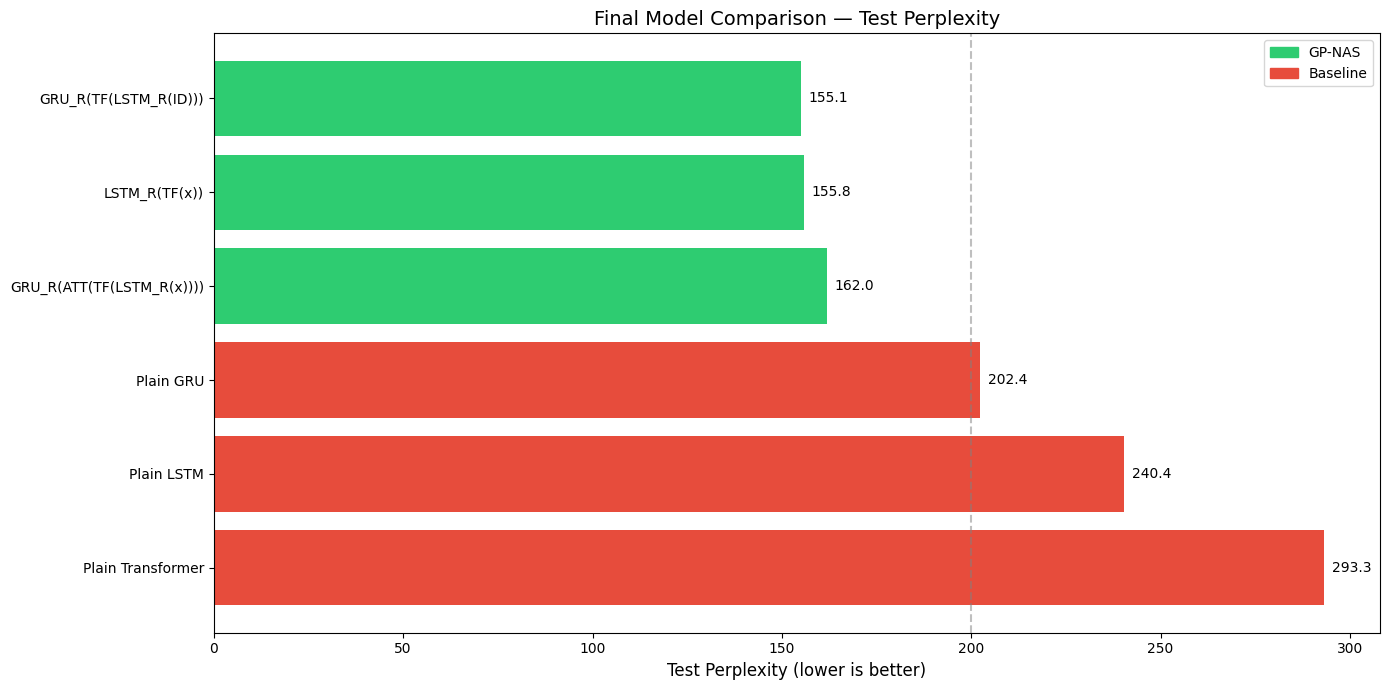

Saved: 01_final_comparison.png


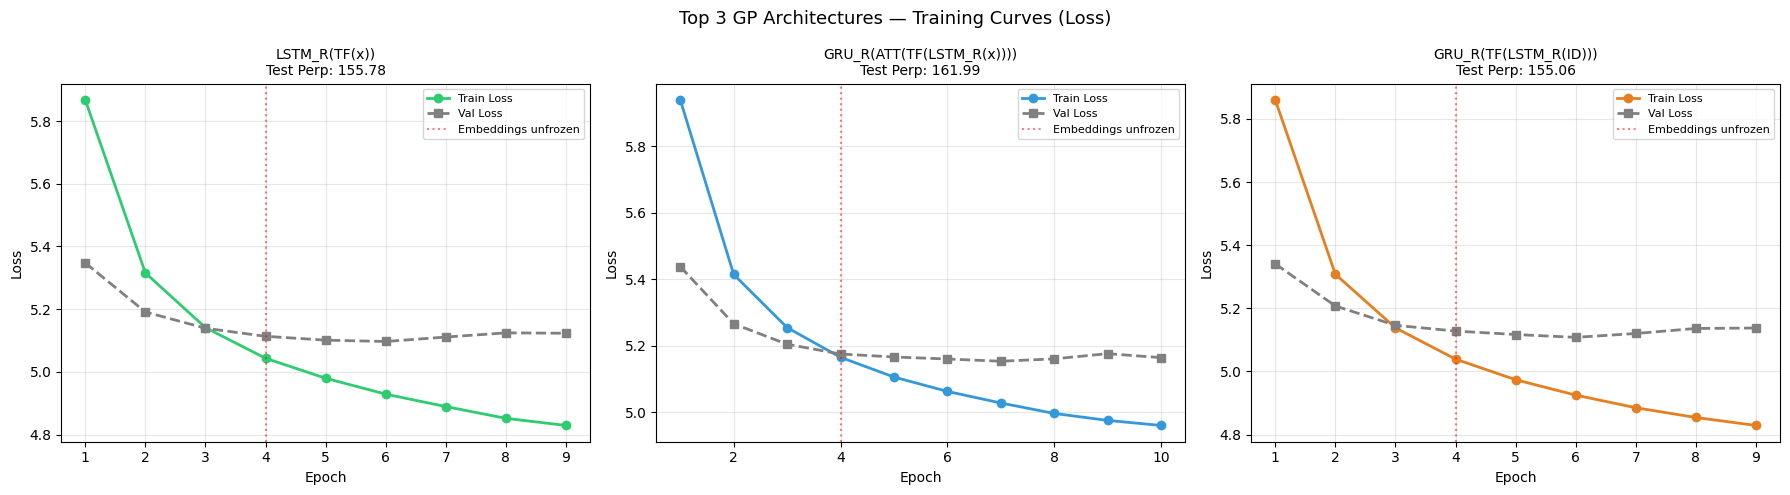

Saved: 02_top3_loss_curves.png


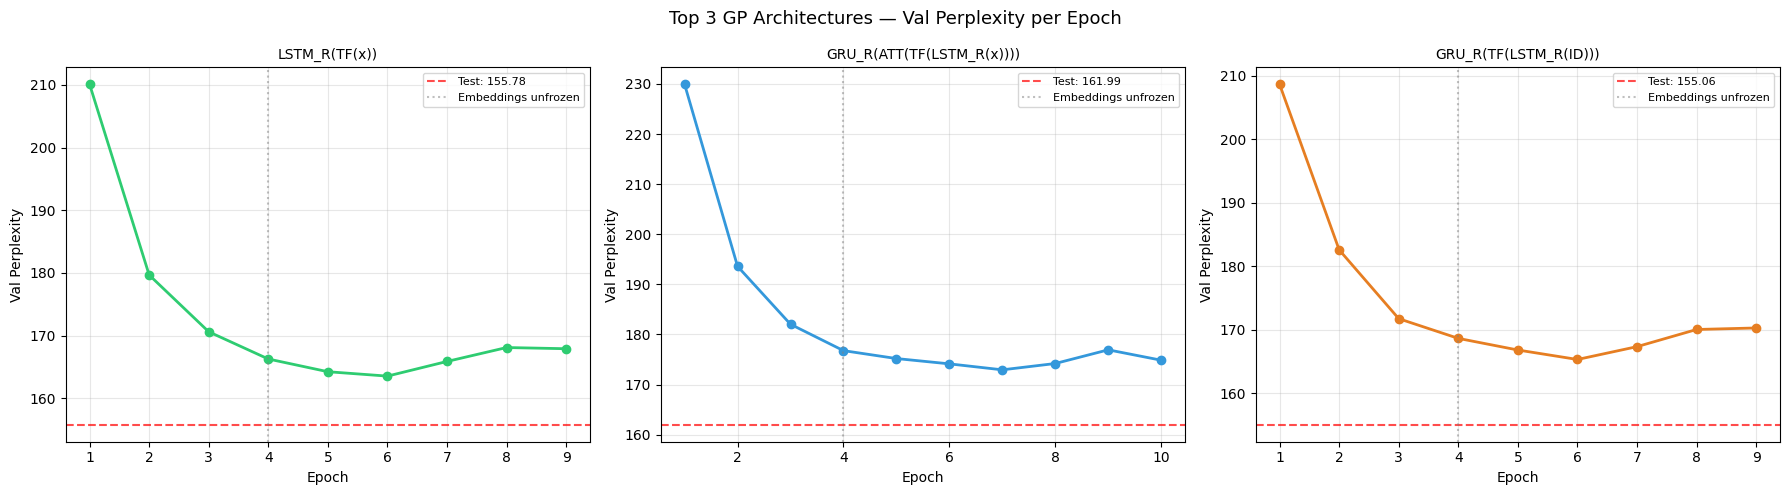

Saved: 03_top3_perplexity_curves.png


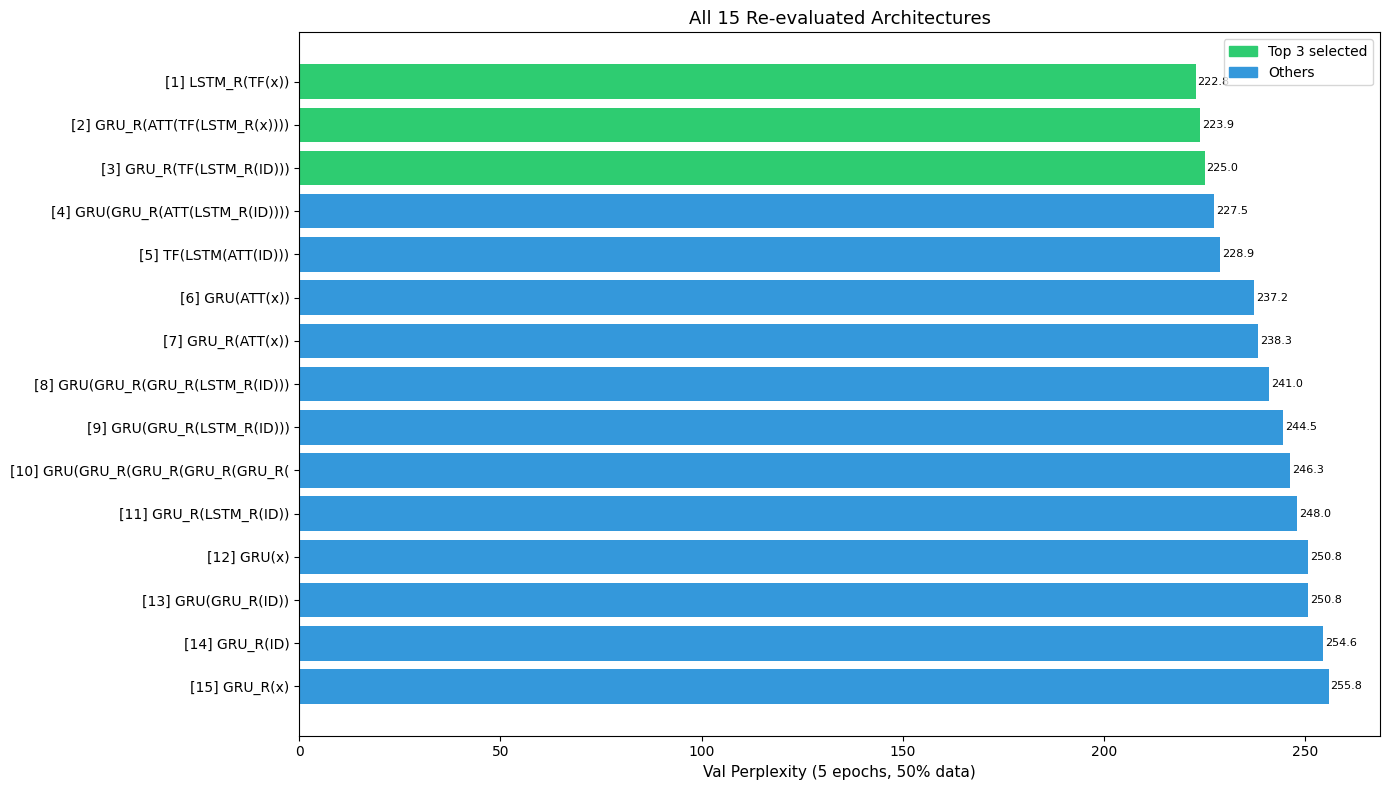

Saved: 04_all15_reeval.png


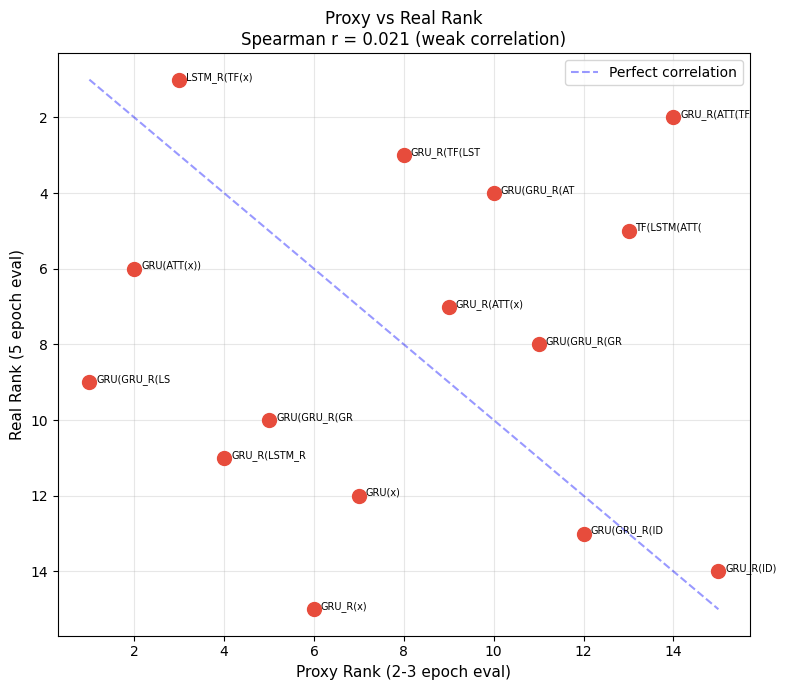

Saved: 05_proxy_vs_real_rank.png  (Spearman r=0.021)


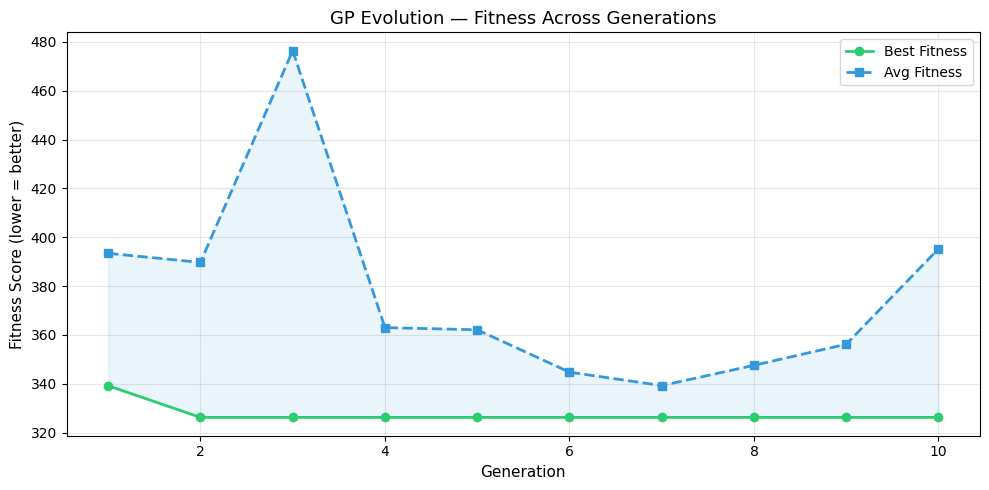

Saved: 06_gp_fitness_curve.png


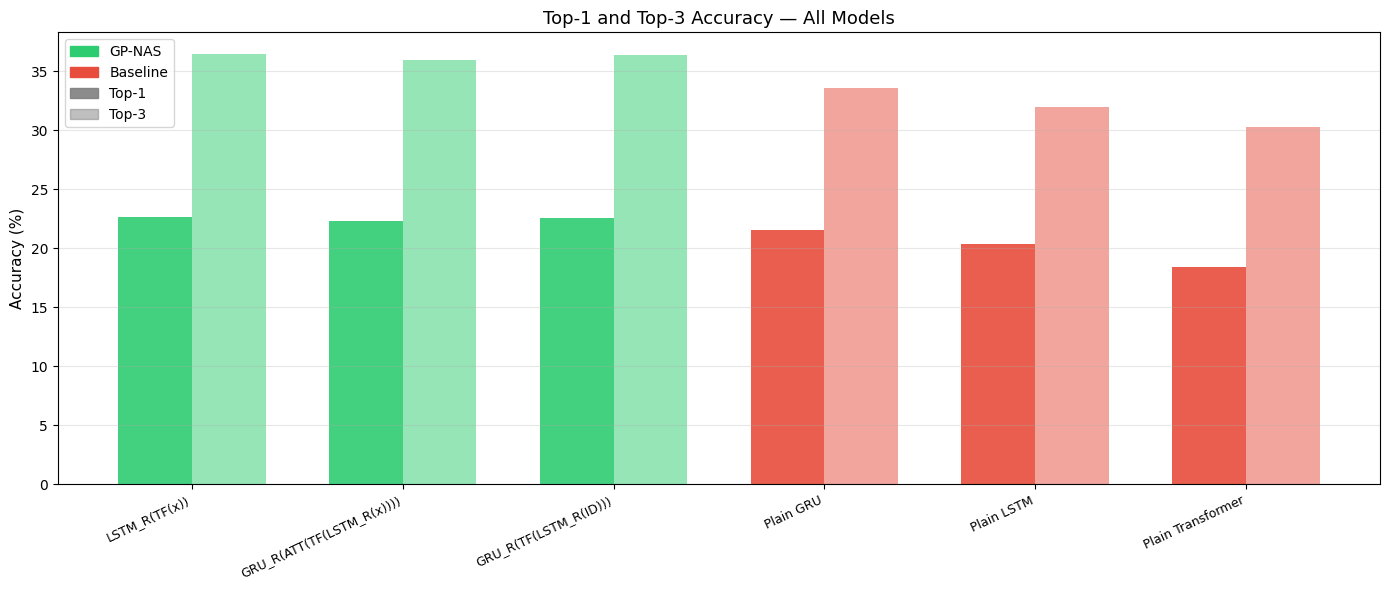

Saved: 07_accuracy_comparison.png


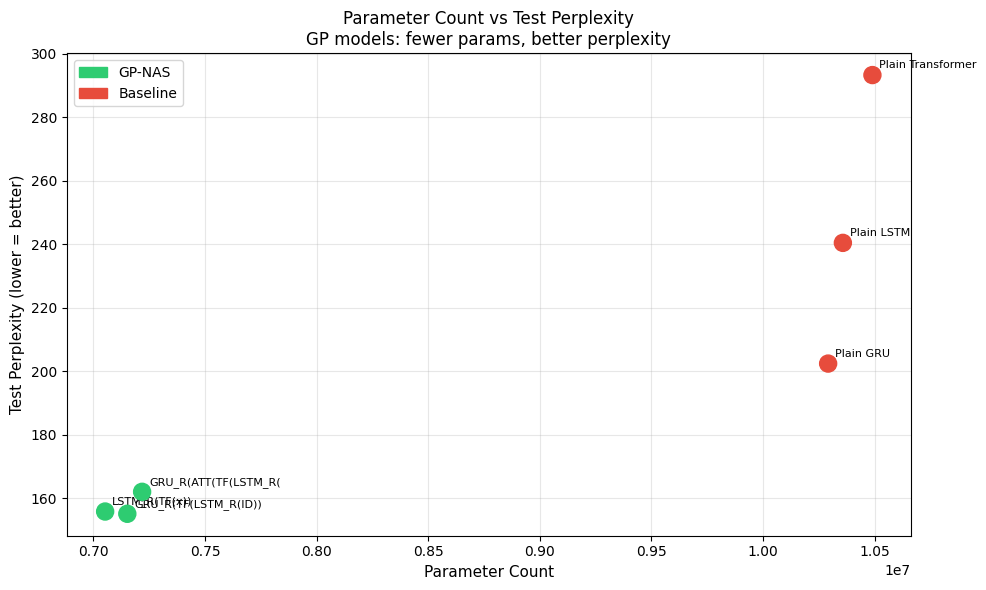

Saved: 08_params_vs_perplexity.png


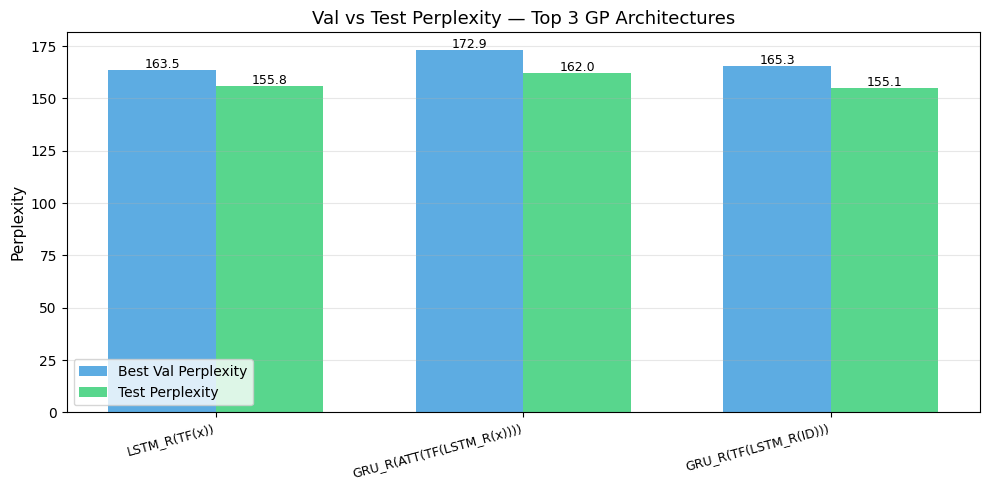

Saved: 09_val_vs_test_perplexity.png

All visualizations saved to:
  /content/drive/MyDrive/GP_NAS/visualizations/

Files saved:
  01_final_comparison.png
  02_top3_loss_curves.png
  03_top3_perplexity_curves.png
  04_all15_reeval.png
  05_proxy_vs_real_rank.png
  06_gp_fitness_curve.png
  07_accuracy_comparison.png
  08_params_vs_perplexity.png
  09_val_vs_test_perplexity.png


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 7.3 — All Visualizations
# Generates and saves all plots to Drive:
# 1. Final comparison bar chart (all models)
# 2. Top 3 GP training curves (loss + perplexity per epoch)
# 3. All 15 re-eval architectures ranked by perplexity
# 4. Proxy vs Real rank scatter
# 5. GP generation fitness curve
# 6. Top1/Top3 accuracy comparison
# 7. Parameter count vs perplexity scatter
# All saved to /GP_NAS/visualizations/
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import json
import os

VIZ_DIR = os.path.join(DRIVE_BASE, 'visualizations/')
os.makedirs(VIZ_DIR, exist_ok=True)

# ── Load all data ─────────────────────────────────────────────────
with open(os.path.join(DRIVE_BASE, 'top3_full_training_results.json')) as f:
    gp_top3 = json.load(f)

with open(os.path.join(DRIVE_BASE, 'reeval_results.json')) as f:
    reeval_results = json.load(f)

with open(os.path.join(DRIVE_BASE, 'gp_run_summary.json')) as f:
    gp_summary = json.load(f)

with open(os.path.join(DRIVE_BASE, 'final_comparison_table.json')) as f:
    comparison = json.load(f)

baseline_data = {
    'Plain GRU'        : {'test_perplexity': 202.39, 'test_top1_acc': 21.57,
                          'test_top3_acc': 33.59, 'params': 10291819},
    'Plain LSTM'       : {'test_perplexity': 240.42, 'test_top1_acc': 20.39,
                          'test_top3_acc': 31.97, 'params': 10357867},
    'Plain Transformer': {'test_perplexity': 293.29, 'test_top1_acc': 18.42,
                          'test_top3_acc': 30.29, 'params': 10490219},
}

print("All data loaded. Generating visualizations...")

# ─────────────────────────────────────────────────────────────────
# Plot 1 — Final Comparison Bar Chart
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

names  = [m['name'][:30] for m in comparison]
perps  = [m['test_perplexity'] for m in comparison]
types  = [m['type'] for m in comparison]
colors = ['#2ecc71' if t == 'GP-NAS' else '#e74c3c' for t in types]

bars = ax.barh(names[::-1], perps[::-1], color=colors[::-1])
ax.set_xlabel('Test Perplexity (lower is better)', fontsize=12)
ax.set_title('Final Model Comparison — Test Perplexity', fontsize=14)
ax.axvline(x=200, color='gray', linestyle='--', alpha=0.5, label='200 threshold')

for bar, perp in zip(bars, perps[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{perp:.1f}', va='center', fontsize=10)

green = mpatches.Patch(color='#2ecc71', label='GP-NAS')
red   = mpatches.Patch(color='#e74c3c', label='Baseline')
ax.legend(handles=[green, red])
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '01_final_comparison.png'), dpi=150)
plt.show()
print("Saved: 01_final_comparison.png")

# ─────────────────────────────────────────────────────────────────
# Plot 2 — Top 3 GP Training Curves (Loss)
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_3  = ['#2ecc71', '#3498db', '#e67e22']

for i, (r, color) in enumerate(zip(gp_top3, colors_3)):
    epochs     = [h['epoch']      for h in r['history']]
    train_loss = [h['train_loss'] for h in r['history']]
    val_loss   = [h['val_loss']   for h in r['history']]

    axes[i].plot(epochs, train_loss, 'o-', color=color,
                 label='Train Loss', linewidth=2)
    axes[i].plot(epochs, val_loss,   's--', color='gray',
                 label='Val Loss',   linewidth=2)
    axes[i].axvline(x=4, color='red', linestyle=':',
                    alpha=0.5, label='Embeddings unfrozen')
    axes[i].set_title(f"{r['tree_string'][:25]}\nTest Perp: {r['test_perplexity']:.2f}",
                      fontsize=10)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Top 3 GP Architectures — Training Curves (Loss)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '02_top3_loss_curves.png'), dpi=150)
plt.show()
print("Saved: 02_top3_loss_curves.png")

# ─────────────────────────────────────────────────────────────────
# Plot 3 — Top 3 GP Training Curves (Perplexity)
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (r, color) in enumerate(zip(gp_top3, colors_3)):
    epochs = [h['epoch']    for h in r['history']]
    perps  = [h['val_perp'] for h in r['history']]

    axes[i].plot(epochs, perps, 'o-', color=color, linewidth=2)
    axes[i].axhline(y=r['test_perplexity'], color='red',
                    linestyle='--', alpha=0.7,
                    label=f"Test: {r['test_perplexity']:.2f}")
    axes[i].axvline(x=4, color='gray', linestyle=':',
                    alpha=0.5, label='Embeddings unfrozen')
    axes[i].set_title(f"{r['tree_string'][:25]}", fontsize=10)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Val Perplexity')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Top 3 GP Architectures — Val Perplexity per Epoch', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '03_top3_perplexity_curves.png'), dpi=150)
plt.show()
print("Saved: 03_top3_perplexity_curves.png")

# ─────────────────────────────────────────────────────────────────
# Plot 4 — All 15 Re-eval Architectures
# ─────────────────────────────────────────────────────────────────
sorted_reeval = sorted(reeval_results, key=lambda x: x['val_perplexity'])

fig, ax = plt.subplots(figsize=(14, 8))
r_labels = [f"[{i+1}] {r['tree_string'][:28]}"
            for i, r in enumerate(sorted_reeval)]
r_perps  = [r['val_perplexity'] for r in sorted_reeval]
r_colors = ['#2ecc71' if i < 3 else '#3498db'
            for i in range(len(sorted_reeval))]

ax.barh(r_labels[::-1], r_perps[::-1], color=r_colors[::-1])
ax.set_xlabel('Val Perplexity (5 epochs, 50% data)', fontsize=11)
ax.set_title('All 15 Re-evaluated Architectures', fontsize=13)

for j, (label, perp) in enumerate(zip(r_labels[::-1], r_perps[::-1])):
    ax.text(perp + 0.5, j, f'{perp:.1f}', va='center', fontsize=8)

green = mpatches.Patch(color='#2ecc71', label='Top 3 selected')
blue  = mpatches.Patch(color='#3498db', label='Others')
ax.legend(handles=[green, blue])
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '04_all15_reeval.png'), dpi=150)
plt.show()
print("Saved: 04_all15_reeval.png")

# ─────────────────────────────────────────────────────────────────
# Plot 5 — Proxy vs Real Rank Scatter
# ─────────────────────────────────────────────────────────────────
sorted_by_real = sorted(reeval_results, key=lambda x: x['val_perplexity'])
proxy_ranks    = [r['rank'] for r in sorted_by_real]
real_ranks     = list(range(1, len(sorted_by_real) + 1))

n         = len(proxy_ranks)
d_sq      = sum((p-r)**2 for p, r in zip(proxy_ranks, real_ranks))
spearman  = 1 - (6 * d_sq) / (n * (n**2 - 1))

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(proxy_ranks, real_ranks, color='#e74c3c', s=100, zorder=5)

for r in sorted_by_real:
    real_r = sorted_by_real.index(r) + 1
    ax.annotate(r['tree_string'][:12],
                (r['rank'], real_r),
                fontsize=7,
                xytext=(5, 0),
                textcoords='offset points')

ax.plot([1, 15], [1, 15], 'b--', alpha=0.4, label='Perfect correlation')
ax.set_xlabel('Proxy Rank (2-3 epoch eval)', fontsize=11)
ax.set_ylabel('Real Rank (5 epoch eval)', fontsize=11)
ax.set_title(f'Proxy vs Real Rank\nSpearman r = {spearman:.3f} '
             f'({"weak" if spearman < 0.4 else "moderate"} correlation)',
             fontsize=12)
ax.legend()
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '05_proxy_vs_real_rank.png'), dpi=150)
plt.show()
print(f"Saved: 05_proxy_vs_real_rank.png  (Spearman r={spearman:.3f})")

# ─────────────────────────────────────────────────────────────────
# Plot 6 — GP Generation Fitness Curve
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
gens    = gp_summary['generations']
best_f  = gp_summary['best_fitness']
avg_f   = gp_summary['avg_fitness']

ax.plot(gens, best_f, 'o-', color='#2ecc71',
        label='Best Fitness', linewidth=2)
ax.plot(gens, avg_f,  's--', color='#3498db',
        label='Avg Fitness',  linewidth=2)
ax.fill_between(gens, best_f, avg_f, alpha=0.1, color='#3498db')
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Fitness Score (lower = better)', fontsize=11)
ax.set_title('GP Evolution — Fitness Across Generations', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '06_gp_fitness_curve.png'), dpi=150)
plt.show()
print("Saved: 06_gp_fitness_curve.png")

# ─────────────────────────────────────────────────────────────────
# Plot 7 — Top1 / Top3 Accuracy Comparison
# ─────────────────────────────────────────────────────────────────
fig, ax  = plt.subplots(figsize=(14, 6))
all_names  = ([r['tree_string'][:25] for r in gp_top3] +
               list(baseline_data.keys()))
all_top1   = ([r['test_top1_acc'] for r in gp_top3] +
               [v['test_top1_acc'] for v in baseline_data.values()])
all_top3   = ([r['test_top3_acc'] for r in gp_top3] +
               [v['test_top3_acc'] for v in baseline_data.values()])
all_colors = (['#2ecc71'] * 3 + ['#e74c3c'] * 3)

x      = np.arange(len(all_names))
width  = 0.35

bars1 = ax.bar(x - width/2, all_top1, width,
               label='Top-1 Accuracy', color=all_colors, alpha=0.9)
bars2 = ax.bar(x + width/2, all_top3, width,
               label='Top-3 Accuracy', color=all_colors, alpha=0.5)

ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Top-1 and Top-3 Accuracy — All Models', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(all_names, rotation=25, ha='right', fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

green = mpatches.Patch(color='#2ecc71', label='GP-NAS')
red   = mpatches.Patch(color='#e74c3c', label='Baseline')
ax.legend(handles=[green, red,
          mpatches.Patch(color='gray', alpha=0.9, label='Top-1'),
          mpatches.Patch(color='gray', alpha=0.5, label='Top-3')])
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '07_accuracy_comparison.png'), dpi=150)
plt.show()
print("Saved: 07_accuracy_comparison.png")

# ─────────────────────────────────────────────────────────────────
# Plot 8 — Params vs Perplexity Scatter
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

all_params = ([r['params'] for r in gp_top3] +
               [v['params'] for v in baseline_data.values()])
all_perps  = ([r['test_perplexity'] for r in gp_top3] +
               [v['test_perplexity'] for v in baseline_data.values()])
all_labels = ([r['tree_string'][:20] for r in gp_top3] +
               list(baseline_data.keys()))
all_colors = (['#2ecc71'] * 3 + ['#e74c3c'] * 3)

ax.scatter(all_params, all_perps, c=all_colors, s=150, zorder=5)

for label, px, py in zip(all_labels, all_params, all_perps):
    ax.annotate(label, (px, py),
                fontsize=8,
                xytext=(5, 5),
                textcoords='offset points')

ax.set_xlabel('Parameter Count', fontsize=11)
ax.set_ylabel('Test Perplexity (lower = better)', fontsize=11)
ax.set_title('Parameter Count vs Test Perplexity\n'
             'GP models: fewer params, better perplexity', fontsize=12)

green = mpatches.Patch(color='#2ecc71', label='GP-NAS')
red   = mpatches.Patch(color='#e74c3c', label='Baseline')
ax.legend(handles=[green, red])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '08_params_vs_perplexity.png'), dpi=150)
plt.show()
print("Saved: 08_params_vs_perplexity.png")

# ─────────────────────────────────────────────────────────────────
# Plot 9 — Val vs Test Perplexity for Top 3
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

labels   = [r['tree_string'][:25] for r in gp_top3]
val_perps  = [r['best_val_perp']   for r in gp_top3]
test_perps = [r['test_perplexity'] for r in gp_top3]

x     = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, val_perps,  width,
       label='Best Val Perplexity',  color='#3498db', alpha=0.8)
ax.bar(x + width/2, test_perps, width,
       label='Test Perplexity', color='#2ecc71', alpha=0.8)

for i, (v, t) in enumerate(zip(val_perps, test_perps)):
    ax.text(i - width/2, v + 1, f'{v:.1f}',
            ha='center', fontsize=9)
    ax.text(i + width/2, t + 1, f'{t:.1f}',
            ha='center', fontsize=9)

ax.set_ylabel('Perplexity', fontsize=11)
ax.set_title('Val vs Test Perplexity — Top 3 GP Architectures', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '09_val_vs_test_perplexity.png'), dpi=150)
plt.show()
print("Saved: 09_val_vs_test_perplexity.png")

# ─────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"All visualizations saved to:")
print(f"  {VIZ_DIR}")
print(f"\nFiles saved:")
files = sorted(os.listdir(VIZ_DIR))
for f in files:
    print(f"  {f}")
print(f"{'='*55}")